## Set things up

### Import libraries
Add directory with the CIBUSmod to path and import CIBUSmod and other packages for handling data and plotting

In [4]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up session
Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`, in this case we only use default data by setting `scenario_workbooks` to `None`

In [5]:
# Create session
session = cm.Session(
    name = 'base_year',
    data_path = '../data'
)

# Add scenarios
session.add_scenario(
    name = 'base year',
    scenario_workbooks = None,
    years = '2020'
)

# Add scenarios
session.add_scenario(
    name = 'base year (x0 crop areas)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.2)',
    scenario_workbooks = None,
    years = '2020'
)

session.add_scenario(
    name = 'base year (sp=0.8)',
    scenario_workbooks = None,
    years = '2020'
)

A scenario with the name 'base year' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (x0 crop areas)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.2)' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'base year (sp=0.8)' already exists use .update_scenario() or .remove_scenario() instead.


### Styling for plots

In [6]:
scn = 'base year'
year = '2020'

bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

pd_bar_style = {
    'kind' : 'bar',
    'cmap' : 'YlGnBu',
    'edgecolor' : 'black',
    'linewidth' : 0.5
}

mekko_style = {
    'cmap' : 'YlGnBu'
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

## Baseline validation

### Animal production compared to statistics

#### Production

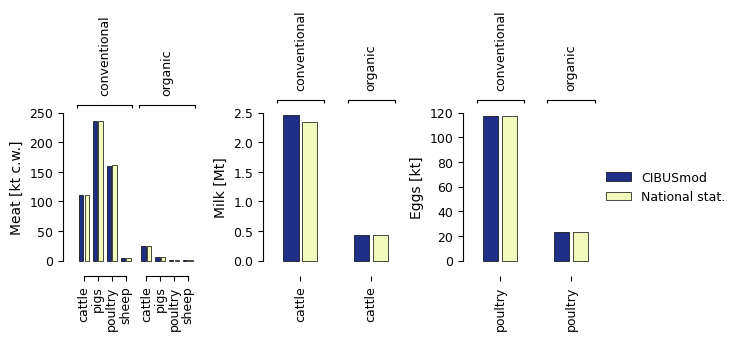

In [29]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','sheep','meat')     : tot_sheep_meat-org_sheep_meat,
        ('organic','sheep','meat')          : org_sheep_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    session.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).loc[(scn,year)].rename('CIBUSmod')/1000000,
    stat.rename('National stat.')
], axis=1)

aps = plot_data.drop('horses', level='species').index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(1,3, figsize=(7.5,3.5))

i=0
for ap in aps:
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.xs(ap,level='animal_prod') * (1/1000 if ap == 'milk' else 1),
        ax = ax,
        ylabel=f'{ap.capitalize()} [{"Mt" if ap == "milk" else "kt"}{" c.w." if ap == "meat" else ""}]',
        stacked = False,
        group_levels='prod_system',
        grouplabels_vertical=True,
        **bar_style
    )
    i+=1

for i, ax in enumerate(axs.flatten()):
    if i == 2:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
    else:
        ax.legend().set_visible(False)
    
plt.tight_layout()
plt.show()

#### Animal numbers

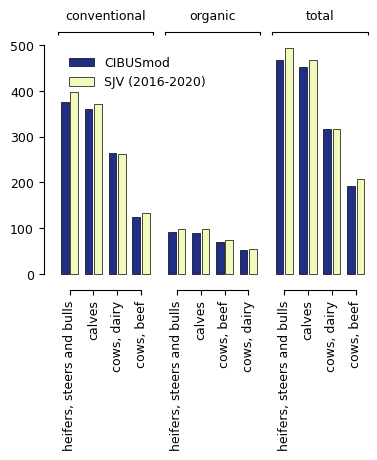

In [30]:
plot_data = session.get_attr('a','heads',{'species':None,'prod_system':None,'breed':None,'animal':None}, 'base year').loc[(scn,year),'cattle'] / 1_000
plot_data.index = pd.MultiIndex.from_tuples(
    [(ps, ', '.join([an, br]) if an == 'cows' else 'calves' if 'calves' in an else 'heifers, steers and bulls') for ps,br,an in plot_data.index],
    names = ['prod_system', 'animal']
)
plot_data = plot_data.groupby(['prod_system','animal']).sum().unstack('prod_system')
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.stack().rename('CIBUSmod')

sjv = pd.Series({
    ('cows, dairy', 'conventional') : 316_238 * (1 - 0.174),
    ('cows, dairy', 'organic') : 316_238 * 0.174,
    ('cows, dairy', 'total') : 316_238,

    ('cows, beef', 'conventional') : 206_514 * (1 - 0.352),
    ('cows, beef', 'organic') : 206_514 * 0.352,
    ('cows, beef', 'total') : 206_514,

    ('calves', 'conventional') : 467_134.4 * (1 - 0.208),
    ('calves', 'organic') : 467_134.4 * 0.208,
    ('calves', 'total') : 467_134.4,

    ('heifers, steers and bulls', 'conventional') : 493_490.2 * (1 - 0.196),
    ('heifers, steers and bulls', 'organic') : 493_490.2 * 0.196,
    ('heifers, steers and bulls', 'total') : 493_490.2,
}).rename('SJV (2016-2020)') / 1_000
sjv.index.names = ['animal','prod_system']

fig,ax = plt.subplots(figsize=(4,3))
cm.plot.bar(
    pd.concat([plot_data, sjv], axis=1),
    group_levels=['prod_system'],
    stacked=False,
    ax=ax,
    **bar_style,
    sort_xlabels=True
)
plt.show()

### Crop production and use compared to statistics

#### Cereals

In [31]:
data = (
    session.get_attr('c','production')
    .loc[(scn,year)]
    .groupby('crop').sum()
    .loc[['Wheat, winter', 'Wheat, spring','Barley, winter', 'Barley, spring','Oats','Rye']]
    .rename('CIBUSmod')
)/1000000

plot_data = pd.concat([
    data,
    pd.Series([2631,259,112,1353,658,149], index=data.index, name='SCB') # SCB stat database. Total harvest. Average 2016-2020
], axis=1)


cm.plot.bar(
    plot_data,
    stacked = False,
    ax = ax,
    **bar_style
)
plt.show()

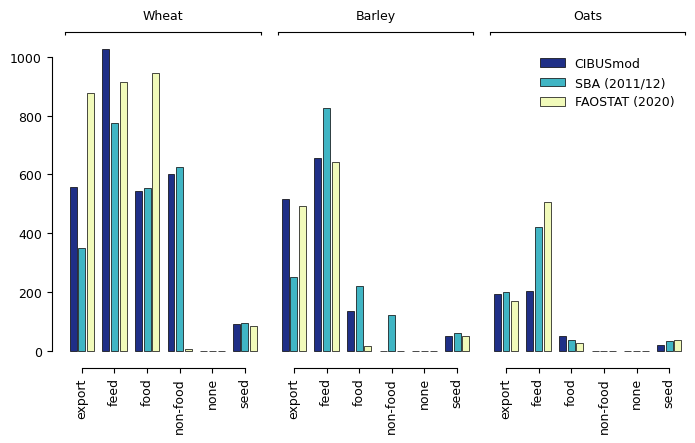

,CIBUSmod,SBA (2011/12),FAOSTAT (2020)
crop,,,
Barley,1 358,1 474,1 204
Oats,466,687,738
Wheat,2 819,2 399,2 827


In [32]:
data = (
    session.get_attr('c','production_per_use')
    .loc[(scn,year)]
    .unstack('demand')
    .groupby('crop')
    .sum()
)/1000000
data.columns = (
    data.columns
    .str.replace('feed.*','feed', regex=True)
)
data = data.T.groupby('demand').sum().T

# Wheat
SBA_1112 = pd.Series([350,775,555,624,0,95], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([1423-545,915,944,6,0,84], index=data.columns, name='FAOSTAT (2020)')

wheat = pd.concat([
    data.loc[['Wheat, winter', 'Wheat, spring'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
wheat = pd.concat({'Wheat': wheat}, names=['crop'])
# plot_data.plot(**bar_style, title='Wheat')
# plt.show()
# print(plot_data.sum())

# Barley
SBA_1112 = pd.Series([250,825,220,120,0,59], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([587-95,644,17,0,0,51], index=data.columns, name='FAOSTAT (2020)')

barley = pd.concat([
    data.loc[['Barley, winter', 'Barley, spring'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
barley = pd.concat({'Barley': barley}, names=['crop'])
# plot_data.plot(**bar_style, title='Barley')
# plt.show()
# print(plot_data.sum())

# Oats
SBA_1112 = pd.Series([200,420,35,0,0,32], index=data.columns, name='SBA (2011/12)')
FAOSTAT2020 = pd.Series([188-20,507,26,0,0,37], index=data.columns, name='FAOSTAT (2020)')

oats = pd.concat([
    data.loc[['Oats'],:].sum().rename('CIBUSmod'),
    SBA_1112,
    FAOSTAT2020
], axis=1)
oats = pd.concat({'Oats': oats}, names=['crop'])
# plot_data.plot(**bar_style, title='Oats')
# plt.show()
# print(plot_data.sum())

plot_data = pd.concat([wheat, barley, oats])

fig, ax = plt.subplots(figsize=(8,4))
cm.plot.bar(
    plot_data,
    group_levels='crop',
    stacked=False,
    **bar_style
)
plt.show()

(
    plot_data
    .groupby('crop').sum()
    .style
    .format(precision=0, thousands=" ")
)

### Manure excretion

#### Volatile solids

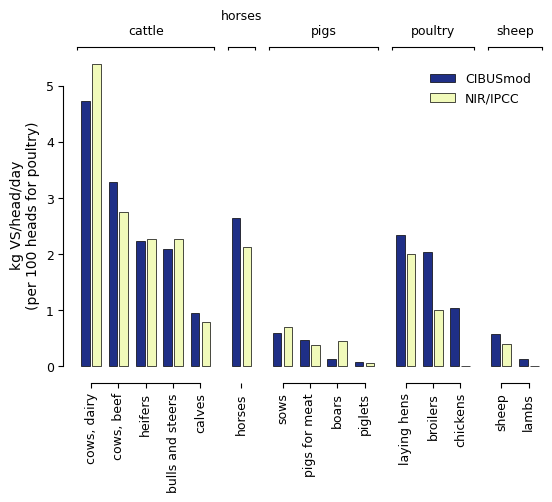

In [33]:
VS = session.get_attr('A','manure.VS_excr',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
heads = session.get_attr('A','heads',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
new_idx = pd.MultiIndex.from_tuples(
    [(sp, f'{an}, {br}')  if an == 'cows' else (sp, an) for sp,br,an in VS.index],
    names = ['species','animal']
)
VS.index = new_idx
heads.index = new_idx
VS = VS.T.groupby(['species','animal']).sum().T
heads = heads.T.groupby(['species','animal']).sum().T
VS_per_head = (VS/heads/365.25).rename('CIBUSmod')


NIR_IPCC = pd.Series({
    # Swedish NIR 2023, Table 5.16
    ('cattle', 'cows, dairy') : 5.39,
    ('cattle', 'cows, beef') : 2.74, # Avg. grazing / stable
    ('cattle', 'calves') : 0.79,
    ('cattle', 'heifers') : 2.26,
    ('cattle', 'bulls and steers') : 2.26,
    ('horses', 'horses') : 2.13,
    ('pigs', 'sows') : 0.69,
    ('pigs', 'boars') : 0.45,
    ('pigs', 'piglets') : 0.044,
    ('pigs', 'pigs for meat') : 0.37,
    # IPCC 2006, Table 10A-9
    ('sheep', 'sheep') : 0.4,
    ('sheep', 'lambs') : np.nan,
    ('poultry','laying hens') : 0.02,
    ('poultry','broilers') : 0.01,
    ('poultry','chickens') : np.nan
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

plot_data = plot_data.mul((plot_data.index.get_level_values('species') == 'poultry') * 99 + 1, axis=0)

fig, ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='species',
    sort_xlabels=True,
    ylabel='kg VS/head/day\n(per 100 heads for poultry)',
    ax=ax,
    **bar_style
)
plt.show()

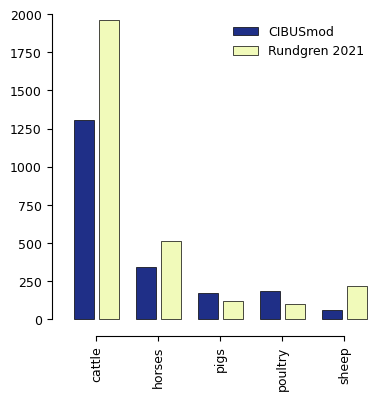

In [34]:
# Compared to Rundgren 2021
plot_data = pd.concat([
    session.get_attr('A','manure.VS_excr','species').loc[(scn,year)].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked = False,
    ax = ax,
    **bar_style
)
plt.show()

#### Nitrogen

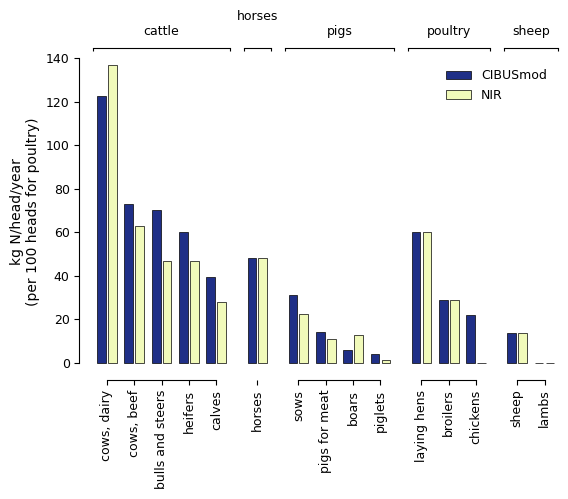

In [35]:
N = session.get_attr('A','manure.N_excr',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
heads = session.get_attr('A','heads',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
N = N.reindex(heads.index)
new_idx = pd.MultiIndex.from_tuples(
    [(sp, f'{an}, {br}')  if an == 'cows' else (sp, an) for sp,br,an in N.index],
    names = ['species','animal']
)
N.index = new_idx
heads.index = new_idx
N = N.T.groupby(['species','animal']).sum().T
heads = heads.T.groupby(['species','animal']).sum().T
N_per_head = (N/heads).rename('CIBUSmod')

# Swedish NIR 2023, Table 5.15 and 5.17
NIR = pd.Series({
    ('cattle','cows, dairy'):137,
    ('cattle','cows, beef'):63,
    ('cattle','calves'):28,
    ('cattle','heifers'):47,
    ('cattle','bulls and steers'):47,
    ('horses','horses') : 48,
    ('pigs','sows') : 22.5,
    ('pigs','boars') : 13,
    ('pigs','piglets') : 1.2,
    ('pigs','pigs for meat') : 10.8,
    ('poultry','laying hens') : 0.6,
    ('poultry','broilers') : 0.29,
    ('poultry','chickens') : np.nan,
    ('sheep', 'sheep') : 14, # includes lambs
    ('sheep','lambs') : 0
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

plot_data = plot_data.mul((plot_data.index.get_level_values('species') == 'poultry') * 99 + 1, axis=0)

fig, ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='species',
    sort_xlabels=True,
    ylabel='kg N/head/year\n(per 100 heads for poultry)',
    ax=ax,
    **bar_style
)
plt.show()

### GHG emissions compared to NIR

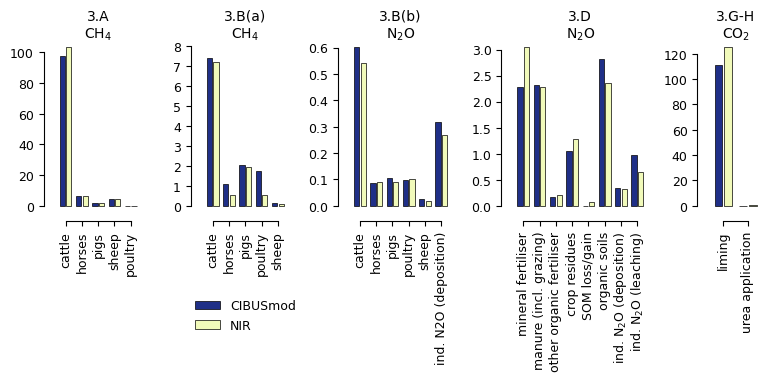

CIBUSmod     NIR        dif
table  compound                                                        
3.A    CH$_4$   cattle                     97.518954  103.12  -5.601046
                horses                      6.399000    6.40  -0.001000
                pigs                        2.102251    2.13  -0.027749
                sheep                       4.319273    4.51  -0.190727
                poultry                          NaN     NaN        NaN
3.B(a) CH$_4$   cattle                      7.392458    7.20   0.192458
                horses                      1.086344    0.55   0.536344
                pigs                        2.065303    1.93   0.135303
                poultry                     1.753217    0.53   1.223217
                sheep                       0.154610    0.11   0.044610
3.B(b) N$_2$O   cattle                      0.600270    0.54   0.060270
                horses                      0.085647    0.09  -0.004353
                pigs                        0.105870    0.09   0.015870
                poultry                     0.096260    0.10  -0.003740
                sheep                       0.027045    0.02   0.007045
                ind. N2O (deposition)       0.318047    0.27   0.048047
3.D    N$_2$O   mineral fertiliser          2.287734    3.04  -0.752266
                manure (incl. grazing)      2.327849    2.28   0.047849
                other organic fertiliser    0.162057    0.20  -0.037943
                crop residues               1.050661    1.28  -0.229339
                SOM loss/gain                    NaN    0.07        NaN
                organic soils               2.812724    2.36   0.452724
                ind. N$_2$O (deposition)    0.349170    0.32   0.029170
                ind. N$_2$O (leaching)      0.965953    0.64   0.325953
3.G-H  CO$_2$   liming                    111.117735  125.00 -13.882265
                urea application                 NaN    0.93        NaN

,CIBUSmod,NIR,dif,%dif
compound,,,,
CH$_4$,122.791409,126.48,-3.688591,-2.916343
CO$_2$,111.117735,125.93,-13.882265,-11.023795
N$_2$O,11.189288,11.30,-0.040712,-0.360286


In [36]:
# Enteric fermentation (Table 3.A) ----------------------------->

cbm = (
    session.get_attr('a','enteric_methane','species')
    .loc[(scn,year)]
    .rename('CIBUSmod')
    /1_000_000
)

nir = pd.Series({
    'cattle':103.12,
    'sheep':4.51,
    'pigs':2.13,
    'poultry':np.nan,
    'horses':6.4
}).rename_axis('species').rename('NIR')

d1 = pd.concat([cbm, nir], axis=1)
d1['dif'] = (d1['CIBUSmod'] - d1['NIR'])
d1 = pd.concat({'CH$_4$': d1}, names=['compound'])
d1 = pd.concat({'3.A': d1}, names=['table'])

# Manure mgmt (Table 3.B(a)) ----------------------------->

cbm = (
    session.get_attr('a','manure.VS_loss',['compound','species'])
    .loc[(scn,year),'CH4bio']
    .rename('CIBUSmod')
    /1_000_000
)

nir = pd.Series({
    'cattle':7.20,
    'sheep':0.11,
    'pigs':1.93,
    'poultry':0.53,
    'horses':0.55
}).rename_axis('species').rename('NIR')

d2 = pd.concat([cbm, nir], axis=1)
d2['dif'] = (d2['CIBUSmod'] - d2['NIR'])
d2 = pd.concat({'CH$_4$': d2}, names=['compound'])
d2 = pd.concat({'3.B(a)': d2}, names=['table'])

# Manure mgmt (Table 3.B(b)) ----------------------------->

cbm_ = (
    session.get_attr('a','manure.N_loss',['compound','species'])
    .loc[(scn,year)]
    .rename('CIBUSmod')
    /1_000_000
)

cbm = cbm_.loc['N2O-N'] * (44/28)
cbm['ind. N2O (deposition)'] = cbm_.loc[['NH3-N','NOx-N']].sum() * 0.010 * (44/28)

nir = pd.Series({
    'cattle':0.54,
    'sheep':0.02,
    'pigs':0.09,
    'poultry':0.10,
    'horses':0.09,
    'ind. N2O (deposition)':0.27
}).rename_axis('species').rename('NIR')

d3 = pd.concat([cbm, nir], axis=1)
d3 = pd.concat({'N$_2$O': d3}, names=['compound'])
d3 = pd.concat({'3.B(b)': d3}, names=['table'])
d3['dif'] = (d3['CIBUSmod'] - d3['NIR'])

# Agricultural soils (Table 3.D) ----------------------------->

cbm = pd.Series({
    'mineral fertiliser' : session.get_attr('c','fertiliser.mineral_N_soil_loss','none').loc[(scn,year)],
    'manure (incl. grazing)' : session.get_attr('c','fertiliser.manure_N_soil_loss','none').loc[(scn,year)],
    'other organic fertiliser' : session.get_attr('c','fertiliser.organic_N_soil_loss','none').loc[(scn,year)],
    'crop residues' : session.get_attr('c','fertiliser.crop_residues_N_soil_loss','none').loc[(scn,year)],
    'SOM loss/gain' : np.nan,
    'organic soils' : session.get_attr('c','fertiliser.organic_soil_N_loss','none').loc[(scn,year)],
    'ind. N$_2$O (deposition)' : (
        session.get_attr('c','fertiliser.mineral_N_application_loss','none').loc[(scn,year)] +
        session.get_attr('c','fertiliser.manure_N_application_loss','none').loc[(scn,year)] +
        session.get_attr('c','fertiliser.organic_N_application_loss','none').loc[(scn,year)]
    ) * 0.010,
    'ind. N$_2$O (leaching)' : session.get_attr('c','fertiliser.leaching_N','none').loc[(scn,year)] * 0.0075
}).rename('CIBUSmod')*(44/28)/1_000_000

nir = pd.Series({
    'mineral fertiliser' : 3.04,
    'manure (incl. grazing)' : 1.10+1.18,
    'other organic fertiliser' : 0.20,
    'crop residues' : 1.28,
    'SOM loss/gain' : 0.07,
    'organic soils' : 2.36,
    'ind. N$_2$O (deposition)' : 0.32,
    'ind. N$_2$O (leaching)' : 0.64
}).rename('NIR')

d4 = pd.concat([cbm, nir], axis=1)
d4 = pd.concat({'N$_2$O': d4}, names=['compound'])
d4 = pd.concat({'3.D': d4}, names=['table'])
d4['dif'] = (d4['CIBUSmod'] - d4['NIR'])

# Liming and Urea (Table 3.G-H) ----------------------------->

cbm = pd.Series({
    'liming' : session.get_attr('c', 'fertiliser.liming_emissions', 'none').loc[(scn,year)]/1_000_000,
    'urea application' : np.nan
}).rename('CIBUSmod')

nir = pd.Series({
    'liming' : 125.00,
    'urea application' : 0.93
}).rename('NIR')

d5 = pd.concat([cbm, nir], axis=1)
d5['dif'] = (d5['CIBUSmod'] - d5['NIR'])
d5 = pd.concat({'CO$_2$': d5}, names=['compound'])
d5 = pd.concat({'3.G-H': d5}, names=['table'])

# Combine and plot ----------------------------->

plot_data = pd.concat([d1,d2,d3,d4,d5])

tab_cmps = plot_data.droplevel(2).index.unique()
lens = [len(plot_data.loc[(tab,cmp)]) for tab,cmp in tab_cmps]

fig, axs = plt.subplots(1,len(lens), figsize=(7.8,4.5), gridspec_kw={'width_ratios': [max(l,3) for l in lens]})

i=0
for tab, cmp in tab_cmps:
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[(tab,cmp),('CIBUSmod','NIR')],
        ax = ax,
        stacked=False,
        **bar_style
    )
    ax.set_title(f'{tab}\n{cmp}', fontsize=10)
    ax.legend().set_visible(False)
    i+=1

axs[1].legend(loc='upper center', fontsize=9, bbox_to_anchor=(0.5, -0.5), ncol=1, frameon=False)

plt.tight_layout()
plt.show()

display(plot_data)

tab_data = plot_data.groupby('compound').sum()
tab_data['%dif'] = tab_data['dif'] / tab_data['NIR'] * 100
display(tab_data)

In [37]:
# Check VS excretion and CH4 from manure management for poultry
print('---------------')
print('kg CH4/head/year (all poultry):')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','compound']).loc[(scn,year),('poultry','CH4bio')] /
session.get_attr('a','heads',['species']).loc[(scn,year),('poultry')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound']).loc[(scn,year),('poultry',slice(None),'CH4bio')] /
session.get_attr('a','heads',['species','breed']).loc[(scn,year),('poultry')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound','animal']).loc[(scn,year),('poultry','broiler','CH4bio')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound','animal']).loc[(scn,year),('poultry','layer','CH4bio')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')])

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed']).loc[(scn,year),('poultry')] /
session.get_attr('a','heads',['species','breed']).loc[(scn,year),('poultry')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed','animal']).loc[(scn,year),('poultry','layer')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day (calc. from 72% DM digestibility):')
print('---------------')
print(session.get_attr('a','feed.consumption',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] / 365.25 * (1-0.72) * (1-0.05))

print('')
print('---------------')
print('kg VS/head/day (calc. from 72% DM digestibility):')
print('---------------')
print(session.get_attr('a','feed.consumption',['species','breed','animal']).loc[(scn,year),('poultry','layer')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')] / 365.25 * (1-0.73) * (1-0.05))

---------------
kg CH4/head/year (all poultry):
---------------
0.07255676809552364

---------------
kg CH4/head/year:
---------------
species  breed    compound
poultry  broiler  CH4bio      0.036398
         layer    CH4bio      0.124050
Name: (base year, 2020), dtype: float64

---------------
kg CH4/head/year:
---------------
animal
breeding hens        0.162367
breeding roosters         NaN
broilers             0.026967
Name: (base year, 2020), dtype: float64

---------------
kg CH4/head/year:
---------------
animal
breeding hens and roosters    0.145941
laying chicks                 0.062960
laying hens (16-28 weeks)     0.150113
laying hens (29-59 weeks)     0.132319
laying hens (>59 weeks)       0.147440
Name: (base year, 2020), dtype: float64

---------------
kg VS/head/day:
---------------
breed
broiler    0.020888
layer      0.020342
Name: (base year, 2020), dtype: float64

---------------
kg VS/head/day:
---------------
animal
breeding hens        0.028845
breeding roosters 

In [38]:
# Check area organic soils
df = session.get_attr('c','area',{'crop':'land_use','region':None}).loc[(scn,year)].unstack('land_use').drop('greenhouse', axis=1)

print('')
print('---------------')
print('Area organic soils [1000 ha]:')
print('---------------')
print((df * (regions.par.get_from_frame('share_org_soil', df)/100)).sum()/1000)


---------------
Area organic soils [1000 ha]:
---------------
land_use
cropland                   137.685767
semi-natural grasslands     38.854690
dtype: float64


In [39]:
# Check crop residues
d1 = session.get_attr('c','crop_residues','residue').loc[(scn,year)]/1_000_000
d2 = session.get_attr('c','crop_residues_harvest','none').loc[(scn,year)]/1_000_000
d3 = d1.copy()
d3.loc['above ground'] -= d2
d4 = session.get_attr('c','fertiliser.crop_residues_N','residue').loc[(scn,year)]/1_000_000
d4.loc['total'] = d4.sum()
d5 = session.get_attr('c','fertiliser.crop_residues_N',{'crop':'crop_group', 'residue':None}).loc[(scn,year)]/1_000_000
d6 = (
    session.get_attr('c','crop_residues_harvest',{'crop':'crop_group'}).div(
        session.get_attr('c','crop_residues',{'residue':None,'crop':'crop_group'}).loc[:,'above ground'], fill_value=0
    )
    
).loc[(scn,year)]

print('')
print('---------------')
print('Generated crop residues [1000 tonnes DM]:')
print('---------------')
print(d1)

print('')
print('---------------')
print('Harvested crop residues [1000 tonnes DM]:')
print('---------------')
print(d2)

print('')
print('---------------')
print('Crop residues left in field [1000 tonnes DM]:')
print('---------------')
print(d3)

print('')
print('---------------')
print('N in crop residues left in field [1000 tonnes N]:')
print('---------------')
print(d4)

print('')
print('---------------')
print('N in crop residues left in field [1000 tonnes N] (NIR 2020):')
print('---------------')
print(pd.Series({'above ground':46.951, 'below ground':40.931, 'total':46.951+40.931}))

print('')
print('---------------')
print('N in crop residues left in field [1000 tonnes N]:')
print('---------------')
print(d5)

print('')
print('---------------')
print('Fraction crop residues removed:')
print('---------------')
print(d6)


---------------
Generated crop residues [1000 tonnes DM]:
---------------
residue
above ground    5220.682830
below ground    2143.166569
Name: (base year, 2020), dtype: float64

---------------
Harvested crop residues [1000 tonnes DM]:
---------------
1581.8560755313824

---------------
Crop residues left in field [1000 tonnes DM]:
---------------
residue
above ground    3638.826754
below ground    2143.166569
Name: (base year, 2020), dtype: float64

---------------
N in crop residues left in field [1000 tonnes N]:
---------------
residue
above ground    40.213746
below ground    26.646504
total           66.860250
Name: (base year, 2020), dtype: float64

---------------
N in crop residues left in field [1000 tonnes N] (NIR 2020):
---------------
above ground    46.951
below ground    40.931
total           87.882
dtype: float64

---------------
N in crop residues left in field [1000 tonnes N]:
---------------
crop_group             residue     
Brassicaceae           above ground   

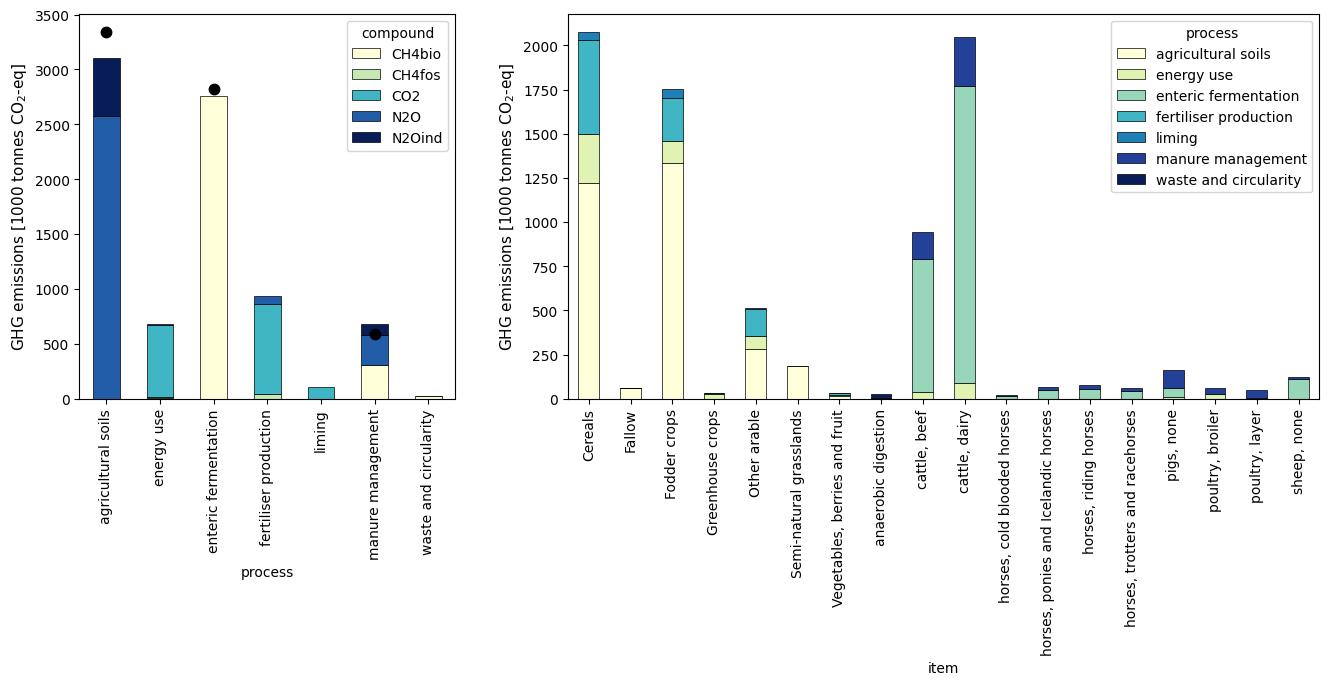

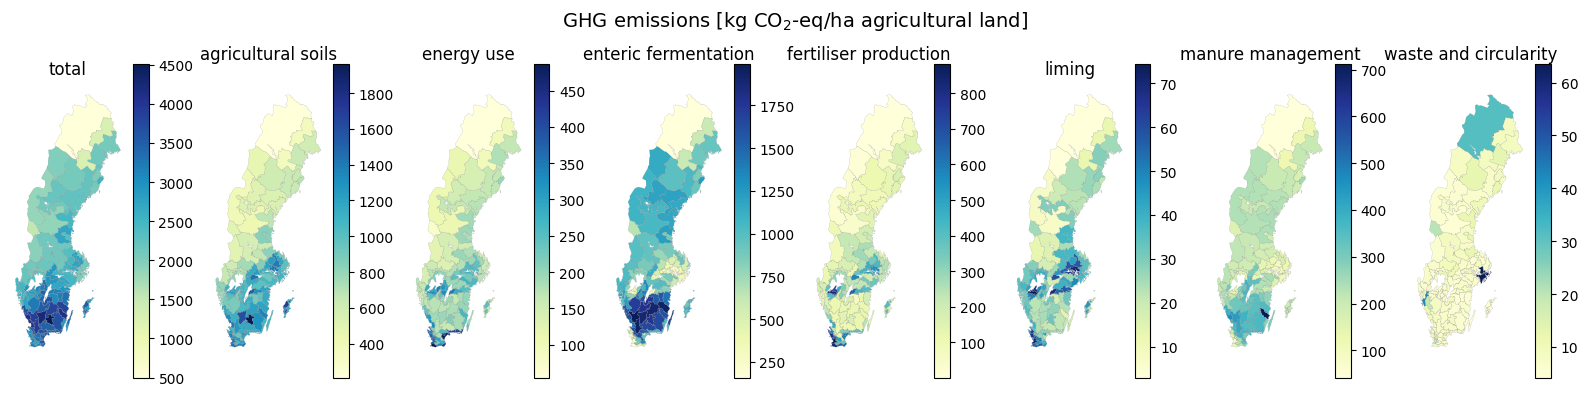

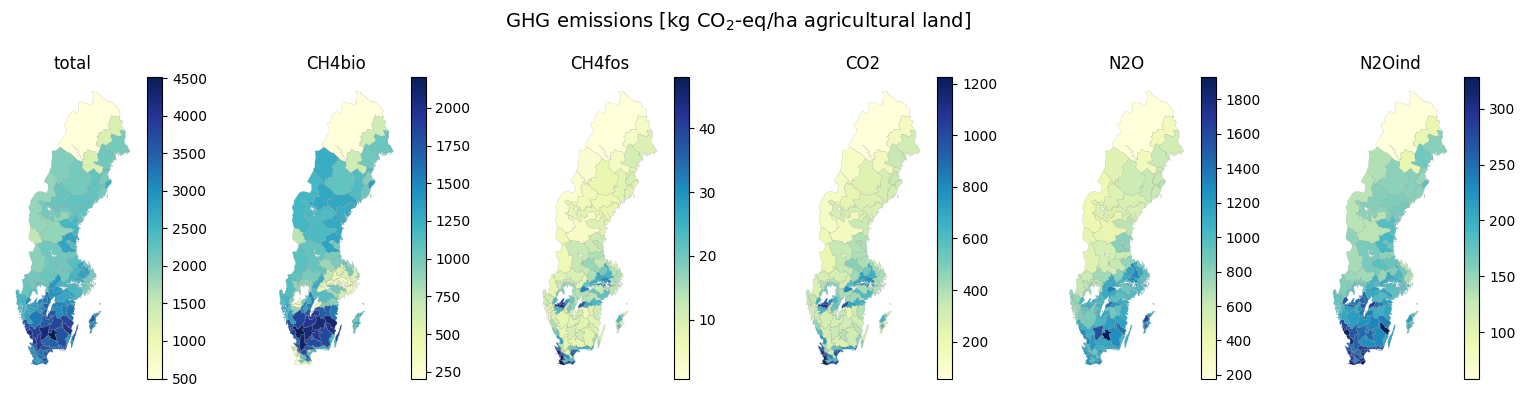

In [40]:
# Bar plot [1000 tonnes CO2eq] ----->

GHG_data = cm.get_GHG(session, scn='base year')

fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
# Avg. 2016-2020 https://www.naturvardsverket.se/data-och-statistik/klimat/vaxthusgaser-utslapp-fran-jordbruk/
plot_data_NIR = pd.Series(
    [3341.2,np.nan,2820.8,np.nan,np.nan,590.8,np.nan]
)

ax=axs[0]
plot_data_NIR.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year)].drop('greenhouse')
    .groupby('region').sum()
)

# per process
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','process'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_proc = len(plot_data.columns)

fig, axs = plt.subplots(1,n_proc+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

# per GHG
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','compound'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_ghg = len(plot_data.columns)

fig, axs = plt.subplots(1,n_ghg+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for cp in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[cp], **map_style, ax=ax)
    ax.set_title(cp)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

### N, P, K application and balances

#### Compared to SCB statistics

In [41]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga areas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total for sweden (SCB, Gödselemedl i jordbruket)
# Avg. 2015/2016, 2018/2019 and 2021/2022
stat_total = pd.Series({ # [1000 tonnes N/P/K]
    ('N','mineral fertiliser') : 170,
    ('N','manure')  : 78,
    ('N','organic fertiliser') : (3590+4370)/2/1000/0.4, # Tablå 3, avg 2018/19 and 2021/22, assuming 40% of N plant available
    ('P','mineral fertiliser') : 13,
    ('P','manure')  : 17,
    ('P','organic fertiliser') : (820+910)/2/1000, # Tablå 3, avg 2018/19 and 2021/22
    ('K','mineral fertiliser') : 29,
    ('K','manure')  : 92,
    ('K','organic fertiliser') : (2960+3110)/2/1000 # Tablå 3, avg 2018/19 and 2021/22
})
stat_crop_tot = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 2.7,
    ('N', 'Other') : 37,
    ('N', 'Ley for fodder') : 79,
    ('N', 'Cereals') : 130,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.3,
    ('P', 'Other') : 6.1,
    ('P', 'Ley for fodder') : 10,
    ('P', 'Cereals') : 14,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 1.7,
    ('K', 'Other') : 22,
    ('K', 'Ley for fodder') : 60,
    ('K', 'Cereals') : 37,
})
stat_crop_tot_mineral = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 1.6,
    ('N', 'Other') : 25,
    ('N', 'Ley for fodder') : 38,
    ('N', 'Cereals') : 106,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.1,
    ('P', 'Other') : 3.4,
    ('P', 'Ley for fodder') : 1.4,
    ('P', 'Cereals') : 8.2,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 0.3,
    ('K', 'Other') : 10,
    ('K', 'Ley for fodder') : 5,
    ('K', 'Cereals') : 13,
})
stat_crop_per_ha = pd.Series({ # [kg N/P/K per ha]
    ('N', 'Not included') : np.nan, # Not incl
    ('N', 'Ley for grazing') : 24,
    ('N', 'Other') : 116,
    ('N', 'Ley for fodder') : 111,
    ('N', 'Cereals') : 133,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 2.9,
    ('P', 'Other') : 20,
    ('P', 'Ley for fodder') : 15,
    ('P', 'Cereals') : 16,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 16,
    ('K', 'Other') : 71,
    ('K', 'Ley for fodder') : 88,
    ('K', 'Cereals') : 44,
})

---------
base year
---------


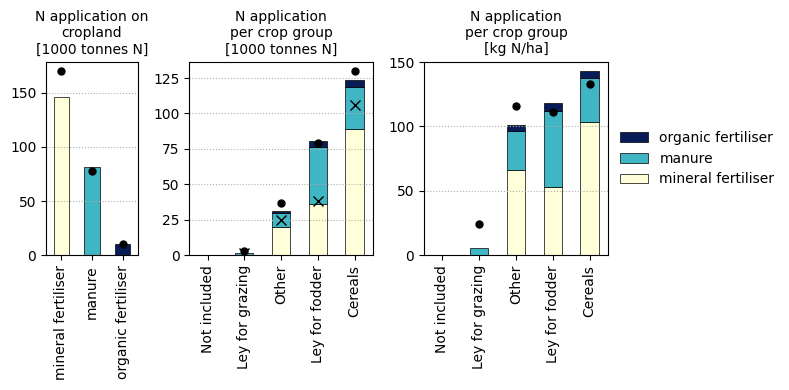

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,146,170,-14
manure,81,78,4
organic fertiliser,10,10,4


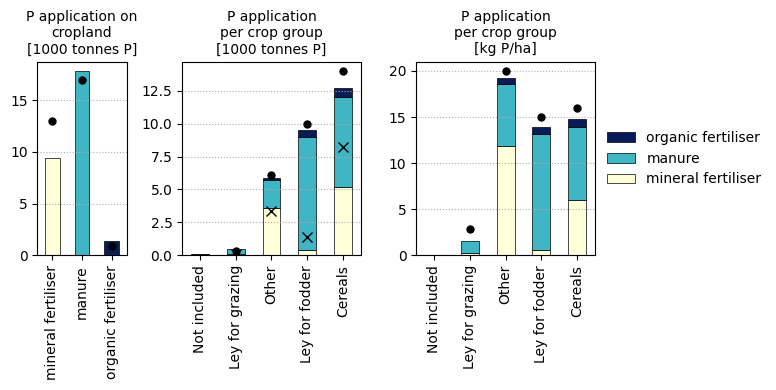

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,9,13,-28
manure,18,17,5
organic fertiliser,1,1,64


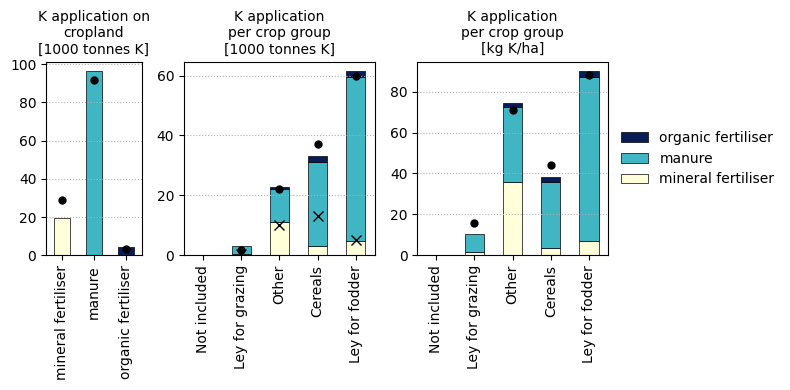

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,20,29,-32
manure,97,92,5
organic fertiliser,5,3,50


-------------------------
base year (x0 crop areas)
-------------------------


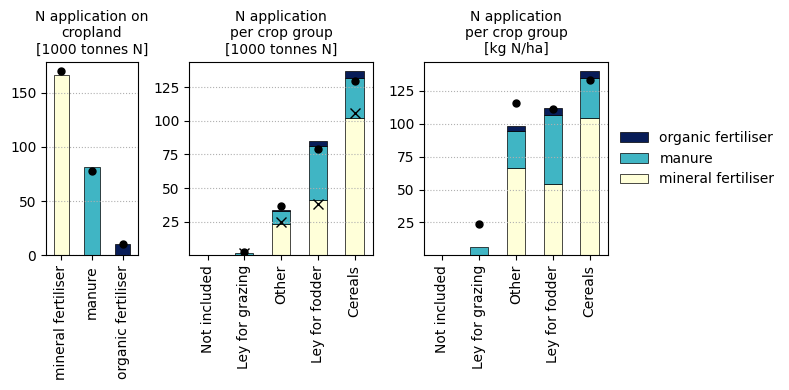

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,167,170,-2
manure,81,78,4
organic fertiliser,10,10,4


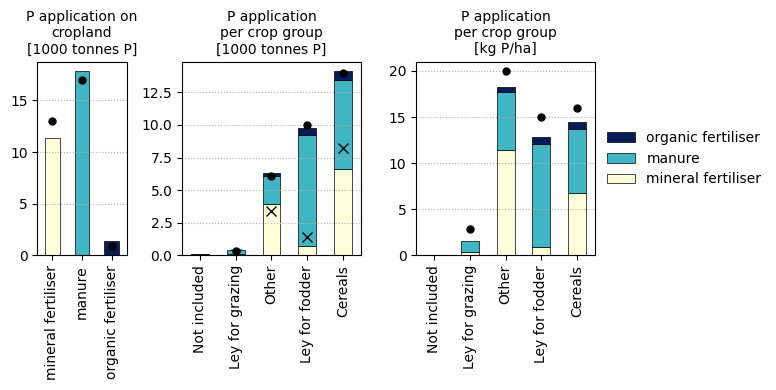

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,11,13,-13
manure,18,17,5
organic fertiliser,1,1,64


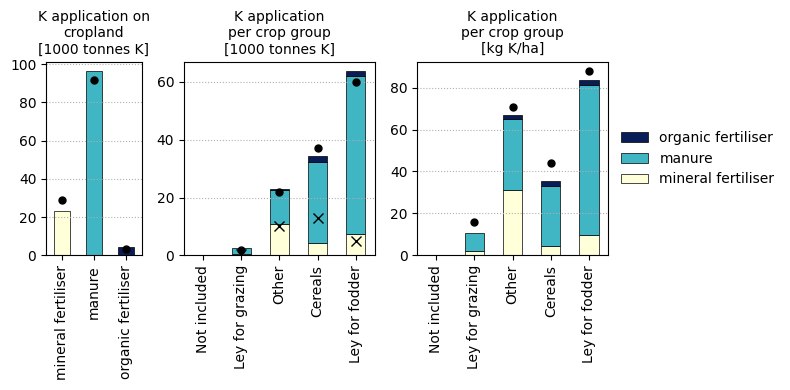

,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,23,29,-20
manure,97,92,5
organic fertiliser,5,3,50


In [42]:
for scn in ['base year', 'base year (x0 crop areas)']:
    print('-'*len(scn), scn, '-'*len(scn), sep='\n')
    for element in ['N','P','K']:
        area = (
            session.get_attr(
                'C',
                'area',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
        )
        mineral_fert = (
            session.get_attr(
                'C',f'fertiliser.mineral_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('mineral fertiliser')
        )
        manure = (
            session.get_attr(
                'C',
                f'fertiliser.manure_{element}',
                {'crop':'crop_group_fertstat', 'MMS':None}
            )
            .loc[(scn,year)]
            .drop('grazing', level='MMS')
            .groupby('crop_group_fertstat')
            .sum()
            .rename('manure')
        )
        organic_fert = (
            session.get_attr(
                'C',f'fertiliser.organic_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('organic fertiliser')
        )
        
        plot_data = pd.concat([mineral_fert, manure, organic_fert], axis=1)/1000000
        plot_data = plot_data.reindex(set(plot_data.index.to_list()+['Not included']), fill_value=0)
        plot_data_tot = plot_data.sum().rename('mineral fertiliser').to_frame()
        plot_data_tot['manure'] = plot_data_tot['mineral fertiliser'] * [0 if i in ['mineral fertiliser','organic fertiliser'] else 1 for i in plot_data_tot.index]
        plot_data_tot['organic fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'organic fertiliser' else 0 for i in plot_data_tot.index]
        plot_data_tot['mineral fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'mineral fertiliser' else 0 for i in plot_data_tot.index]
        
        fig, axs = plt.subplots(1,3, figsize=(8,4), gridspec_kw={'width_ratios': [1, 2, 2]})
        # Total manure and mineral fertiliser [tonnes]
        ax = axs[0]
        plot_data_tot.T.plot(**pd_bar_style, stacked=True, ax = ax, legend=False)
        stat_total.loc[element].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application on\ncropland\n[1000 tonnes {element}]', size=10)
        
        # Manure and mineral fertiliser per crop group
        ax = axs[1]
        s = plot_data.sum(axis=1).sort_values().index
        plot_data.loc[s].plot(**pd_bar_style, stacked=True, ax=ax, legend=False)
        stat_crop_tot.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        stat_crop_tot_mineral.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='x', markersize=7, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application\nper crop group\n[1000 tonnes {element}]', size=10)
        
        # Manure and mineral fertiliser per crop group per area
        ax = axs[2]
        (plot_data.div(area, axis=0)*1000000).loc[s].plot(**pd_bar_style, stacked=True, ax=ax)
        stat_crop_per_ha.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_title(f'{element} application\nper crop group\n[kg {element}/ha]', size=10)
    
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, reverse=True)
        plt.tight_layout()
        plt.show()

        table_data = pd.concat([plot_data_tot.sum().rename('CIBUSmod'), stat_total.loc[element].rename('SCB (2016-2020)')], axis=1)
        table_data['Difference'] = (table_data['CIBUSmod'] - table_data['SCB (2016-2020)']) / table_data['SCB (2016-2020)'] * 100
        display(table_data.style.format(precision=0))
        
scn = 'base year'

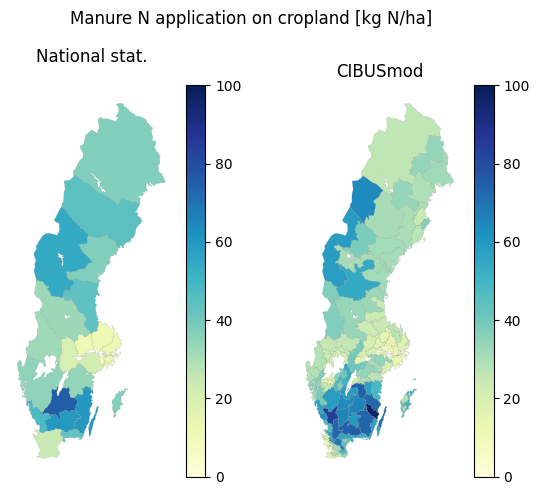

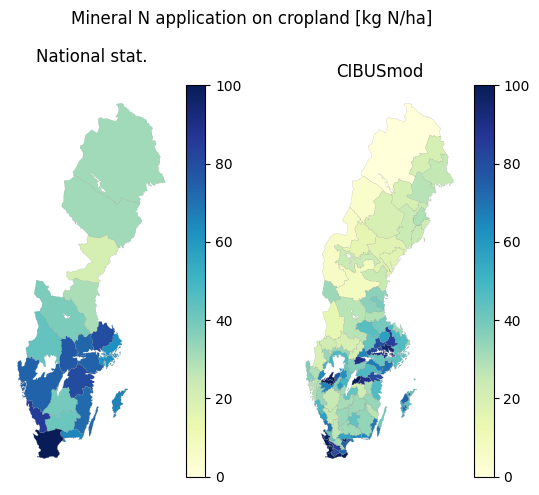

In [43]:
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year),'cropland']
)

# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.manure_N',{'crop':'land_use', 'MMS':None, 'region':None})
    .loc[(scn,year)]
    .drop('grazing', level='MMS')
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Manure N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    session
    .get_attr('C','fertiliser.mineral_N',{'crop':'land_use', 'region':None})
    .loc[(scn,year)]
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]')
plt.tight_layout()
plt.show()

#### For organic areas

,CIBUSmod,SJV (2005),Dif%
crop,,,
Ley for fodder,"4,729","3,666",29
"Barley, spring","3,167","2,440",30
Oats,"2,995","2,460",22
"Wheat, winter","4,416","3,100",42
"Wheat, spring","2,910","2,980",-2
"Peas, dry","2,620","2,220",18
"Potatoes, table","26,004","10,280",153


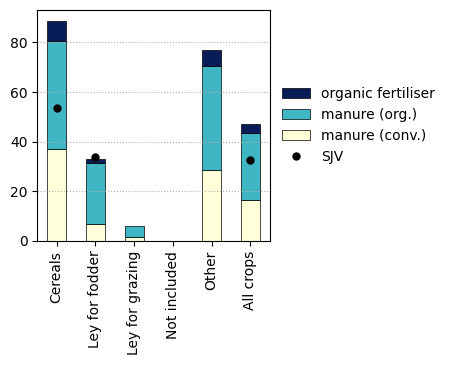

,manure (conv.),manure (org.),organic fertiliser
crop_group_fertstat,,,
Cereals,41.933044,48.999574,9.067382
Ley for fodder,20.111079,74.005647,5.883274
Ley for grazing,23.861574,76.138426,0.000000
Not included,44.180689,46.985420,8.833891
Other,37.286834,54.378097,8.335069
All crops,34.493408,57.719386,7.787206


In [44]:
# SJV (2005) Växtnäringsförsörjning inom Ekologiska produktionsformer – rapport från projektet CAP:s miljöeffekter
# Rapport 2005:13
# Tabell 8 och 12
sjv = pd.Series(
    {'Cereals' : 85 * 0.63, # Tabell 12.1
     'Ley for fodder' : 75 * 0.45, # Tabell 12.2
     'Ley for grazing' : np.nan,
     'Not included' : np.nan,
     'Other' : np.nan,
     'All crops' : 80 * 0.41} # Tabell 8
).rename('SJV')

# Note that yields are generally lower in SJV (2005) compared to current (2016-2020) organic yields used in CIBUSmod
tab_data = (
    (session.get_attr('c','harvest',['prod_system','crop']) / session.get_attr('c','area',['prod_system','crop']))
    .loc[(scn,year),'organic']
    .loc[['Ley for fodder','Barley, spring','Oats','Wheat, winter','Wheat, spring','Peas, dry','Potatoes, table']]
    .rename('CIBUSmod')
).to_frame()
tab_data['SJV (2005)'] = [4_390 * (1-0.165), 2_440, 2_460, 3_100, 2_980, 2_220, 10_280]
tab_data['Dif%'] = (tab_data['CIBUSmod'] - tab_data['SJV (2005)']) / tab_data['SJV (2005)'] * 100
display(tab_data.style.format("{:,.0f}"))

area = (
    session.get_attr(
        'C',
        'area',
        {'prod_system':None, 'crop':'crop_group_fertstat'}
    )
    .loc[(scn,year),'organic']
)
manure = (
    session.get_attr(
        'C',
        'fertiliser.manure_N',
        {'prod_system':None, 'crop':'crop_group_fertstat', 'animal_prod_system':None, 'MMS':None}
    )
    .loc[(scn,year)]
    .drop('grazing', level='MMS')
    .groupby(['prod_system','crop_group_fertstat','animal_prod_system'])
    .sum()
    .unstack()
    .rename(columns={'conventional':'manure (conv.)', 'organic':'manure (org.)'})
    .loc['organic']
)
organic_fert = (
    session.get_attr(
        'C','fertiliser.organic_N',
        {'prod_system':None, 'crop':'crop_group_fertstat'}
    )
    .loc[(scn,year),'organic']
    .rename('organic fertiliser')
)

cbm = pd.concat([manure, organic_fert], axis=1).fillna(0).div(area, axis=0)
cbm.loc['All crops'] = pd.concat([manure, organic_fert], axis=1).drop('Not included').sum() / area.drop('Not included').sum()

fig,ax = plt.subplots(figsize=(3,3))
cbm.plot(stacked=True, ax=ax, **pd_bar_style)
sjv.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')

ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
ax.grid('on', linestyle=':', which='both', axis='y')
ax.set_xlabel('')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, reverse=True)

plt.show()

display(cbm.div(cbm.sum(axis=1), axis=0) * 100)

#### Compared to Einarsson et al (2022)

In [45]:
excr = session.get_attr('a','manure.N_excr','none').loc[[(scn,year)]].rename('excretion')
excr.index = pd.Index(['N'], name='compound')
to_treatment = session.get_attr('a','manure.N_to_treatment','none').loc[[(scn,year)]]
to_treatment.index = pd.Index(['N'], name='compound')
to_spread = (
    session.get_attr('a','manure.N_to_spread','none').loc[[(scn,year)]] +
    session.get_attr('w','organic_fertiliser_N',['feedstock_type']).loc[[(scn,year)], 'manure']
).rename('to spread')
to_spread.index = pd.Index(['N'], name='compound')
loss = (
    session.get_attr('a','manure.N_loss',['compound']).loc[(scn,year)].add(
        session.get_attr('w','losses_N',['feedstock_type', 'compound']).loc[(scn,year), 'manure'],
        fill_value=0
    )
).rename('losses')
appl_loss = pd.concat([
    session.get_attr('c','fertiliser.manure_N_soil_loss','compound').loc[(scn,year)],
    session.get_attr('c','fertiliser.manure_N_application_loss','compound').loc[(scn,year)]
]).rename('application/soil loss')

cibus = pd.concat([excr, loss, to_spread, appl_loss], axis=1).fillna(0).rename_axis('stage', axis=1)/1_000_000
cibus = pd.concat({'CIBUSmod': cibus}, names=['source'], axis=1)

Einarsson_data = {
    'index': ['N', 'N2', 'N2O-N', 'NH3-N', 'NOx-N'],
    'columns': [('Einarsson et al (2022)', i) for i in ['excretion', 'losses', 'to spread', 'application/soil loss']],
    'data': [[134.02, 0,         39.82+72.45, 0],
             [0,      3.92,      0,           0],
             [0,      0.51,      0,           0.69+72.45*0.01],
             [0,      7.31+9.88, 0,           3.10+12.69],
             [0,      0.13,      0,           0]],
    'index_names': ['compound'],
    'column_names': ['source', 'stage']
}
Einarsson = pd.DataFrame.from_dict(Einarsson_data, orient='tight')

plot_data = pd.concat([cibus, Einarsson], axis=1)

In [46]:
table_data = plot_data.stack('stage').replace({0:np.nan}).dropna(how='all').reorder_levels([1,0]).sort_index()
table_data['Diferance'] = (table_data['CIBUSmod'] - table_data['Einarsson et al (2022)']) / table_data['Einarsson et al (2022)'] * 100
display(table_data.style.format(precision=2))

In [47]:
# Share of excretion lost
plot_data.sum().groupby('source').apply(lambda x: x.loc[(slice(None),'losses')].sum()/x.loc[(slice(None),'excretion')].sum()*100)

source
CIBUSmod                  17.415577
Einarsson et al (2022)    16.228921
dtype: float64

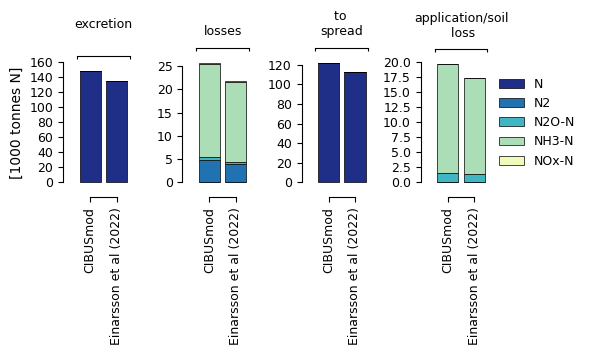

In [48]:
fig, axs = plt.subplots(1,4, figsize=(6,3.5))

for i, s in enumerate(plot_data.columns.unique('stage')):
    ax = axs[i]
    d = plot_data.T.loc[(slice(None),s),:]
    cm.plot.bar(
        d,
        stacked = True,
        group_levels='stage',
        ylabel='[1000 tonnes N]' if i==0 else '',
        ax = ax,
        **bar_style
    )
    if i < len(axs) - 1:
        ax.legend().remove()
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

#### N inputs to conventional and organic cropland

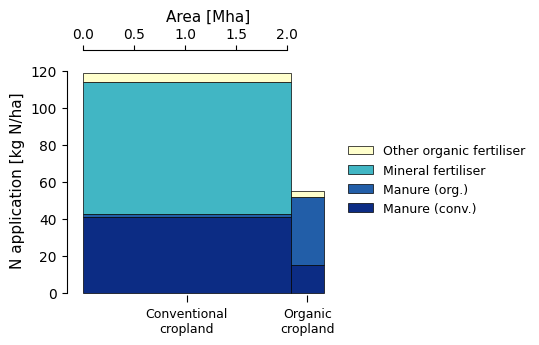

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,34.103800,1.187313,59.280997,3.744217
Organic\ncropland,27.168995,66.102070,NaN,6.133652


In [49]:
mi = (
    session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
)
ma = (
    session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
    .unstack()
    .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
)

oo = (
    session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
)

ar = (
    session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
)

plot_data = pd.concat([
    ma.div(ar, axis=0),
    mi.div(ar, axis=0).rename('Mineral fertiliser'),
    oo.div(ar, axis=0).rename('Other organic fertiliser'),
    ar.rename('area')/1_000_000
], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})

from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(3.3,3))

cm.plot.marimekko(
    plot_data.fillna(0),
    ax=ax,
    x_column='area',
    cmap=cust_cmap,
    sort_categories=False,
    xlim_pad = 0.05,
    ylim_pad = 0.04,
    xcategorylabels_rotation=0,
    xcategorylabels_halign='center',
    ylabel='N application [kg N/ha]',
    xlabel='Area [Mha]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)

plt.show()

display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)

### Waste treatment

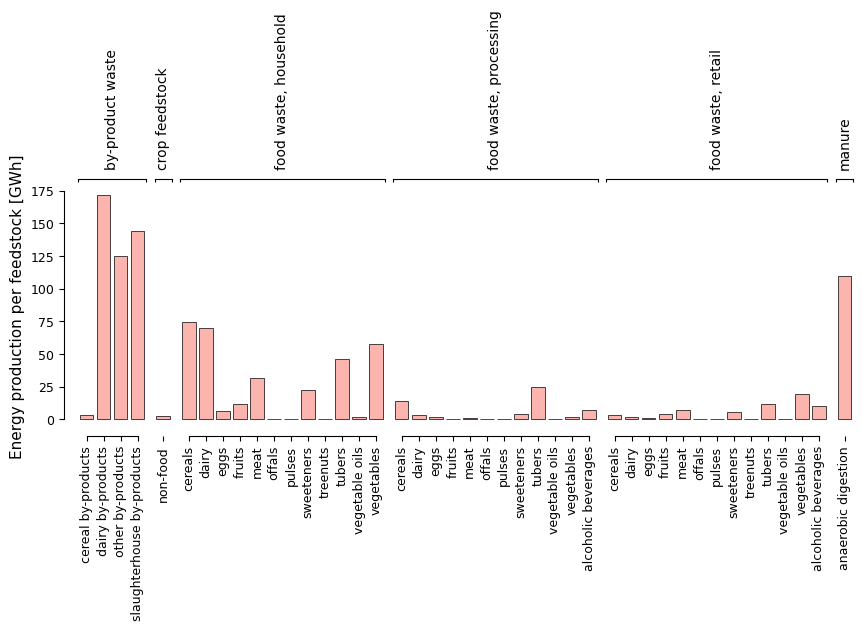

In [50]:
plot_data = (
    session.get_attr('w', 'energy_prod', ['feedstock_type', 'feedstock_group', 'treatment'])
    .loc[(scn,year)]
    .unstack()
)/1000000 # GWh

fig, ax = plt.subplots(figsize=(10,3))
cm.plot.bar(
    plot_data,
    group_levels='feedstock_type',
    ticklabels_fontsize=9,
    grouplabels_vertical=True,
    cmap='Pastel1',
    ylabel='Energy production per feedstock [GWh]'
)
plt.show()

In [51]:


print('2016 (alla anläggningar)')
tot_2016 = 2_018 #GWh
print('food waste:',tot_2016 * 11/100,'GWh')
print('manure:',tot_2016 * 19/100,'GWh')
print('food industry:',tot_2016 * 10/100,'GWh')

print('\n2020 (alla anläggningar)')
tot_2020 = 2_161 #GWh
print('food waste:',tot_2020 * 21/100,'GWh')
print('manure:',tot_2020 * 11/100,'GWh')
print('food industry:',tot_2020 * 7/100,'GWh')

print('\n2022 (samrötning)')
tot_2022 = 1_145 #GWh
print('food waste:',round(tot_2022 * ((426*148)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('manure:',round(tot_2022 * ((661*26)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('food industry:',round(tot_2022 * ((293*66)/(426*148+661*26+293*66+186*120+204*100))),'GWh')

print('\nCIBUSmod energy production [GWh]')
print(session.get_attr('w','energy_prod').loc[(scn,year)].groupby(['treatment','feedstock_type']).sum()/1000000)

print(
    '',
    '---------------------------',
    'Total N in feedstocks to AD',
    '---------------------------',
    sep='\n'
)
print(
    'Swe IIR 2023 Table 6-11 (avg 2016-2020):',
    round((13_139+12_934+13_880+15_119+15_017)/5),
    't N'
)
print(
    'CIBUSmod:',
    round(session.get_attr('w','feedstock_N').loc[(scn,year)].xs('anaerobic digestion', level='treatment').sum()/1000),
    't N'
)

2016 (alla anläggningar)
food waste: 221.98 GWh
manure: 383.42 GWh
food industry: 201.8 GWh

2020 (alla anläggningar)
food waste: 453.81 GWh
manure: 237.71 GWh
food industry: 151.27 GWh

2022 (samrötning)
food waste: 507 GWh
manure: 138 GWh
food industry: 156 GWh

CIBUSmod energy production [GWh]
treatment            feedstock_type        
anaerobic digestion  by-product waste          444.250739
                     crop feedstock              2.271180
                     food waste, household     324.145806
                     food waste, processing     59.010527
                     food waste, retail         65.052955
                     manure                    109.918486
Name: (base year, 2020), dtype: float64

---------------------------
Total N in feedstocks to AD
---------------------------
Swe IIR 2023 Table 6-11 (avg 2016-2020): 14018 t N
CIBUSmod: 10604 t N


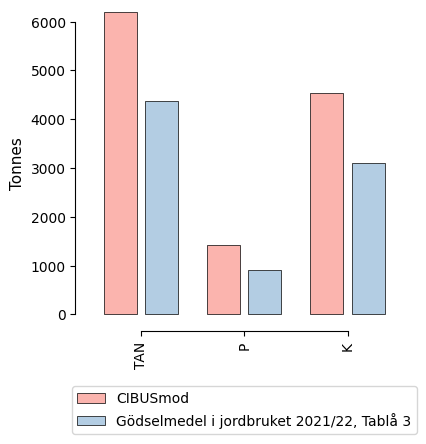

In [52]:

df_Cm = pd.concat([
    session.get_attr('w','organic_fertiliser_TAN',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_P',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_K',['treatment']).loc[(scn,year)]
]).rename('CIBUSmod')/1000
df_Cm.index = ['TAN','P','K']

# "Biogödsel totalt" according to statistics (Gödselmedel i jordbruket 2021/22, Tablå 3)
df_stat = pd.Series({
    'TAN' : 4370,
    'P' : 910,
    'K' : 3110
}).rename('Gödselmedel i jordbruket 2021/22, Tablå 3')

df = pd.concat([df_Cm,df_stat], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(df, stacked=False, cmap='Pastel1', ylabel='Tonnes', ax=ax)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize=10)
plt.show()

### Energy use

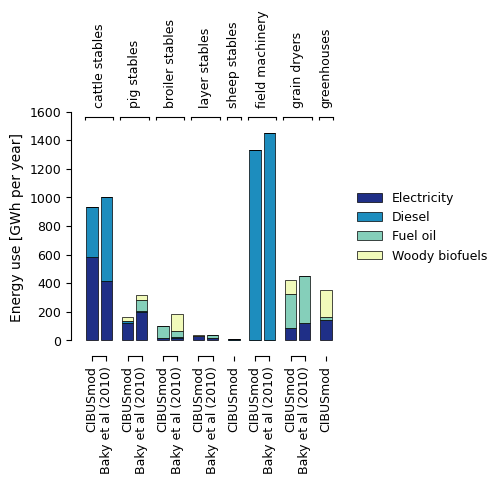

In [53]:
plot_data = (
    session.get_attr('A','energy_use',['species','breed','energy_source'])
    .loc[(scn,year)]
    .rename({'beef':'all','dairy':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)
idx = pd.MultiIndex.from_tuples(
    [('cattle stables','CIBUSmod'),('pig stables','CIBUSmod'),
     ('broiler stables','CIBUSmod'),('layer stables','CIBUSmod'),
    ('sheep stables','CIBUSmod')],
    names=['category','source']
)
plot_data.index = idx
plot_data = plot_data.reindex(idx, fill_value=0)

plot_data.loc[('field machinery','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),'field machinery'].rename({'Biodiesel':'Diesel'})
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('grain dryers','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['grain dryers', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('greenhouses','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['greenhouses', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('cattle stables','Baky et al (2010)'),:]  = [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pig stables','Baky et al (2010)'),:]     = [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broiler stables','Baky et al (2010)'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layer stables','Baky et al (2010)'),:]   = [      19,       0.2,     19,       0 ]
plot_data.loc[('field machinery','Baky et al (2010)'),:] = [       0,      1449,      0,       0 ]
plot_data.loc[('grain dryers','Baky et al (2010)'),:] =    [     125,         0,      325,     0 ]

plot_data = plot_data.fillna(0)

fig, ax = plt.subplots(figsize=(3.2,3))
cm.plot.bar(plot_data, group_levels='category', ylabel='Energy use [GWh per year]', grouplabels_vertical=True, ax=ax, **bar_style)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=9, frameon=False)
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

In [54]:
(
    session.get_attr('A','energy_use','energy_source').add(
        session.get_attr('C','energy_use','energy_source'),
        fill_value=0
    )
    .loc[(scn,year)]
    /1_000_000
)

energy_source
Biodiesel             38.448782
Diesel              1656.958258
District heating      24.032949
Electricity          897.459822
Fuel oil             344.260065
Geothermal             2.588982
Natural gas           28.115930
Woody biofuels       334.035218
Name: (base year, 2020), dtype: float64

In [55]:
plot_data.xs('CIBUSmod', level='source').sum()

energy_source
Electricity        984.203544
Diesel            1695.407040
Fuel oil           344.260065
Woody biofuels     334.035218
dtype: float64

In [56]:
plot_data.xs('CIBUSmod', level='source').sum().sum()

3357.905867550783

### Feed rations and use of by-products

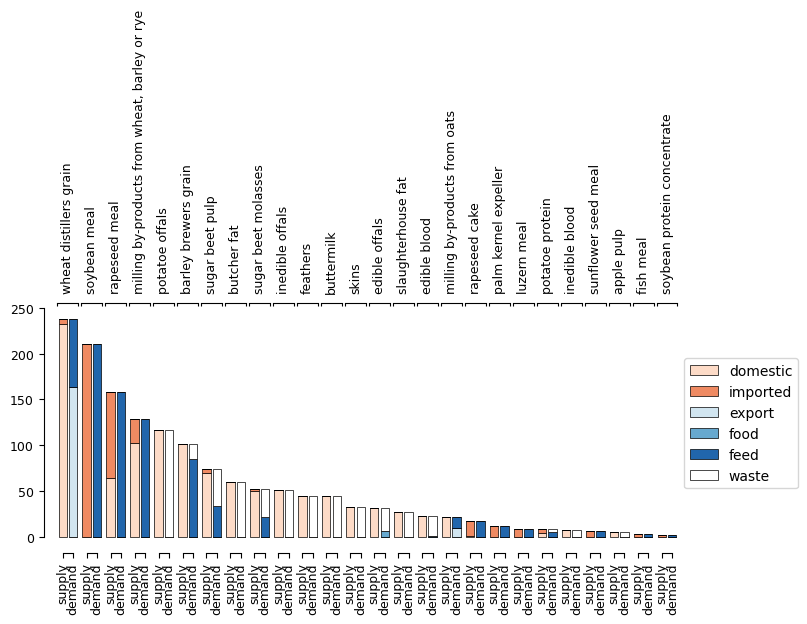

In [57]:
use = pd.concat([
    
    session.get_attr('D', 'by_prod_demand', ['by_prod', 'demand']).loc[(scn,year)].unstack(fill_value=0),
    
    session.get_attr('A', 'feed.by_product_demand', 'by_prod')
    .loc[(scn,year)]
    .rename('feed'),

    session.get_attr('D', 'by_prod_to_waste', 'by_prod').loc[(scn,year)]
    .rename('waste')
    
], axis=1).fillna(0).rename_axis('origin', axis=1)

supply = (
    session.get_attr('D', 'by_products', ['by_prod', 'origin'])
    .loc[(scn,year)]
    .unstack()
    .fillna(0)
)

plot_data = pd.concat([
    pd.concat({'supply': 
       supply
      }, names=['flow'], axis=1),
    
    pd.concat({'demand': 
       use
      }, names=['flow'], axis=1)
], axis=1).stack('flow').sort_index(level='flow', ascending=False).sort_index(level='by_prod', sort_remaining=False).fillna(0)/1000000

from matplotlib.colors import ListedColormap
colors = ['#fddbc7', '#ef8a62', '#d1e5f0', '#67a9cf', '#2166ac', '#ffffff']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(1,1, figsize=(8,3))
ax, axgs = cm.plot.bar(
    plot_data.drop('whey'),
    ax=ax,
    cmap = cust_cmap,
    group_levels='by_prod',
    sort_groups=True,
    grouplabels_vertical=True,
    group_spacing = 0.3,
    ticklabels_fontsize = 9,
    grouplabels_fontsize = 9,
    ylabel_fontsize = 10,
    xlabel_fontsize = 10
)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

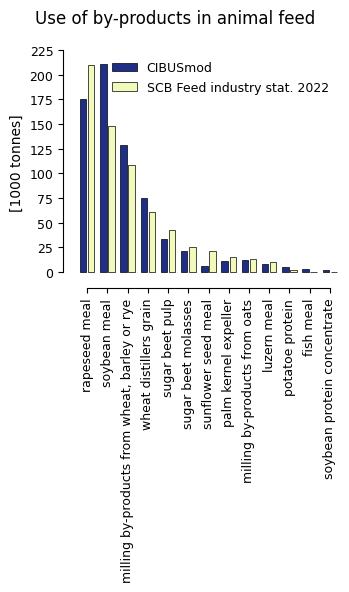

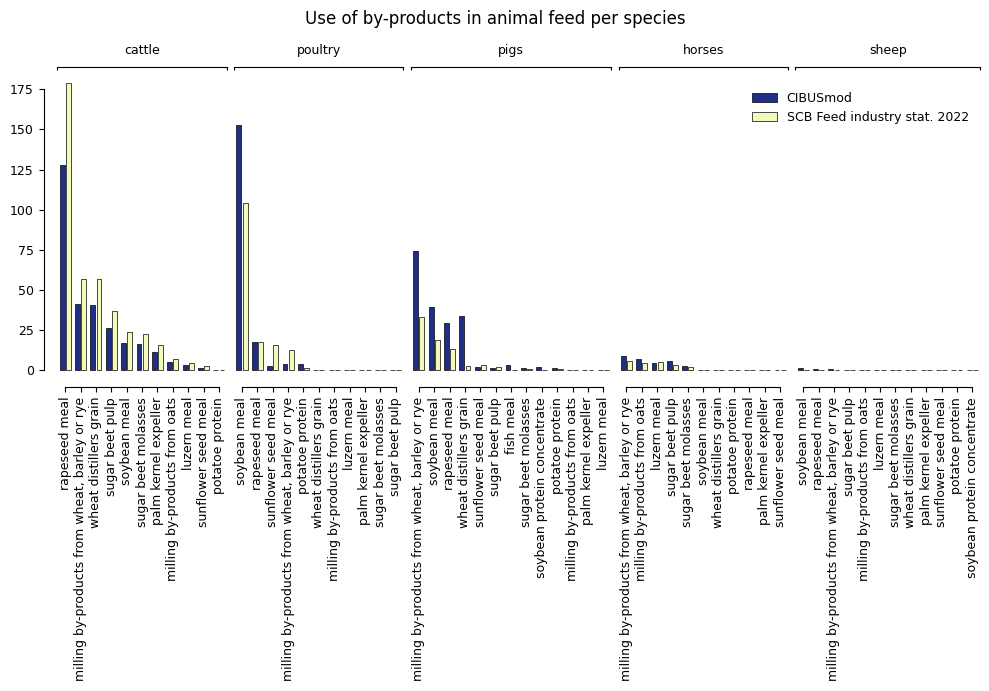

In [58]:
data = (
    session.get_attr('A','feed.by_product_demand')
    .loc[(scn,year)]
    .rename({'rapeseed cake' : 'rapeseed meal'})
    .groupby(['species','by_prod']).sum()
    .rename('CIBUSmod')
)/1000000

SCB_2022_feed_industry_stat = pd.Series({
    
    ('cattle','wheat distillers grain') : 56.803,
    ('cattle','rapeseed meal') : 178.628,
    ('cattle','milling by-products from wheat, barley or rye') : 57.085,
    ('cattle','sugar beet pulp') : 36.933,
    ('cattle','sugar beet molasses') : 22.689,
    ('cattle','soybean meal') : 23.656,
    ('cattle','palm kernel expeller') : 15.770,
    ('cattle','milling by-products from oats') : 7.277,
    ('cattle','luzern meal') : 4.850,
    ('cattle','sunflower seed meal') : 2.427,
    ('cattle','potatoe protein') : 0.166,

    ('horses','wheat distillers grain') : 0.199,
    ('horses','rapeseed meal') : 0.004,
    ('horses','milling by-products from wheat, barley or rye') : 5.745,
    ('horses','milling by-products from oats') : 4.646,
    ('horses','sugar beet pulp') : 3.495,
    ('horses','sugar beet molasses') : 1.812,
    ('horses','soybean meal') : 0.500,
    ('horses','palm kernel expeller') : 0.000,
    ('horses','luzern meal') : 5.355,
    ('horses','sunflower seed meal') : 0.000,
    ('horses','potatoe protein') : 0.016,

    ('pigs','wheat distillers grain') : 3.007, # A lot fed wet not through feed industry?
    ('pigs','rapeseed meal') : 13.057,
    ('pigs','milling by-products from wheat, barley or rye') : 33.011,
    ('pigs','milling by-products from oats') : 0.467,
    ('pigs','barley brewers grain') : np.nan, # Not in data, not going through feed industry??
    ('pigs','whey') : np.nan, # Not in data, not going through feed industry??
    ('pigs','sugar beet pulp') : 2.314,
    ('pigs','sugar beet molasses') : 0.767,
    ('pigs','soybean meal') : 19.069,
    ('pigs','palm kernel expeller') : 0.065,
    ('pigs','luzern meal') : 0.116,
    ('pigs','sunflower seed meal') : 3.581,
    ('pigs','potatoe protein') : 0.864,

    ('poultry','wheat distillers grain') : 0.489,
    ('poultry','rapeseed meal') : 17.796,
    ('poultry','milling by-products from wheat, barley or rye') : 12.408,
    ('poultry','milling by-products from oats') : 0.440,
    ('poultry','sugar beet pulp') : 0.000,
    ('poultry','sugar beet molasses') : 0.000,
    ('poultry','soybean meal') : 104.370,
    ('poultry','palm kernel expeller') : 0.000,
    ('poultry','luzern meal') : 0.236,
    ('poultry','sunflower seed meal') : 15.493,
    ('poultry','potatoe protein') : 1.202,
    
}).rename('SCB Feed industry stat. 2022').rename_axis(['species','by_prod'])

plot_data = pd.concat([data, SCB_2022_feed_industry_stat], axis=1)

# Drop whey and barley brewers grain as these are not going through feed industry???
plot_data = plot_data.drop('whey', level='by_prod')
plot_data = plot_data.drop('barley brewers grain', level='by_prod')

fig, ax = plt.subplots(1,1, figsize=(3.6,6))
ax, axgs = cm.plot.bar(plot_data.groupby('by_prod').sum(), ax=ax, stacked=False, ylabel='[1000 tonnes]', sort_xlabels=True, **bar_style)
plt.suptitle('Use of by-products in animal feed')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax, axgs = cm.plot.bar(plot_data, ax=ax, stacked=False, group_levels='species', sort_xlabels=True, sort_groups=True, **bar_style)
plt.suptitle('Use of by-products in animal feed per species')
plt.tight_layout()
plt.show()



In [59]:
plot_data

CIBUSmod  \
species by_prod                                                     
cattle  luzern meal                                      3.489182   
        milling by-products from oats                    5.234888   
        milling by-products from wheat, barley or rye   41.065422   
        palm kernel expeller                            11.344392   
        potatoe protein                                  0.119632   
        rapeseed meal                                  127.780478   
        soybean meal                                    17.017595   
        sugar beet molasses                             16.490482   
        sugar beet pulp                                 26.568407   
        sunflower seed meal                              1.745850   
        wheat distillers grain                          40.862630   
horses  luzern meal                                      4.493180   
        milling by-products from oats                    7.356437   
        milling by-products from wheat, barley or rye    9.157763   
        potatoe protein                                  0.025857   
        sugar beet molasses                              2.927503   
        sugar beet pulp                                  5.578927   
pigs    fish meal                                        3.418110   
        milling by-products from wheat, barley or rye   74.032518   
        palm kernel expeller                             0.225189   
        potatoe protein                                  1.310214   
        rapeseed meal                                   29.252772   
        soybean meal                                    39.309051   
        soybean protein concentrate                      2.319420   
        sugar beet molasses                              1.564619   
        sugar beet pulp                                  1.217624   
        sunflower seed meal                              1.849555   
        wheat distillers grain                          33.927061   
poultry milling by-products from wheat, barley or rye    3.908971   
        potatoe protein                                  3.662022   
        rapeseed meal                                   17.682228   
        soybean meal                                   152.732239   
        sunflower seed meal                              2.888484   
sheep   luzern meal                                      0.083264   
        milling by-products from oats                    0.144010   
        milling by-products from wheat, barley or rye    0.619385   
        palm kernel expeller                             0.010685   
        potatoe protein                                  0.000224   
        rapeseed meal                                    0.644796   
        soybean meal                                     1.538671   
        soybean protein concentrate                      0.000061   
        sugar beet molasses                              0.073983   
        sugar beet pulp                                  0.189694   
        sunflower seed meal                              0.003722   
        wheat distillers grain                           0.047956   
horses  wheat distillers grain                                NaN   
        rapeseed meal                                         NaN   
        soybean meal                                          NaN   
        palm kernel expeller                                  NaN   
        sunflower seed meal                                   NaN   
pigs    milling by-products from oats                         NaN   
        luzern meal                                           NaN   
poultry wheat distillers grain                                NaN   
        milling by-products from oats                         NaN   
        sugar beet pulp                                       NaN   
        sugar beet molasses                                   NaN   
        palm kernel expeller                           

In [60]:
sel = 'cattle'

table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['species', 'breed', 'animal', 'feed']).loc[(scn,year)]
    .xs(sel)
    .unstack(['breed','animal'], fill_value=0)
    /
    session.get_attr('AnimalHerd', 'heads', ['species', 'breed', 'animal']).loc[(scn,year)]
    .xs(sel)
)

table_data.loc['total',:] = table_data.sum()

print('Unit: kg DM/head')
table_data.style \
.format(precision=1, thousands=" ", decimal=".",)

Unit: kg DM/head


In [61]:
table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['feed', 'species']).loc[(scn,year)]
    .unstack()
).fillna(0)/1000
table_data['total'] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes DM')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes DM


species,cattle,horses,pigs,poultry,sheep,total
feed,,,,,,
barley,326 409,999,222 298,11 126,1 176,562 007
barley brewers grain,0,0,20 868,0,0,20 868
broad beans,12 406,0,46 265,0,64,58 735
fish meal,0,0,3 083,0,0,3 083
grazing,1 020 844,281 844,0,0,106 127,1 408 815
hay,0,738 739,0,0,0,738 739
"ley silage, 1st cut",1 155 572,0,0,0,29 468,1 185 040
"ley silage, regrowth",1 059 781,0,0,0,58 936,1 118 716
linseed,63,0,201,0,2,266


### Forage and pasture use per livestock system

In [62]:
table_data = session.get_attr('AnimalHerd', 'feed.demand', ['feed', 'species', 'breed', 'animal']).loc[(scn,year)]
table_data = (
    table_data
    .loc['grazing']
    /
    table_data
    .loc[['grazing', 'hay', 'ley silage, 1st cut', 'ley silage, regrowth', 'maize silage', 'other silage', 'straw']]
    .groupby(['species','breed','animal'])
    .sum()
    * 100
).fillna(0)

table_data.rename('% grazing').to_frame().style \
.format(precision=1, decimal=".",)

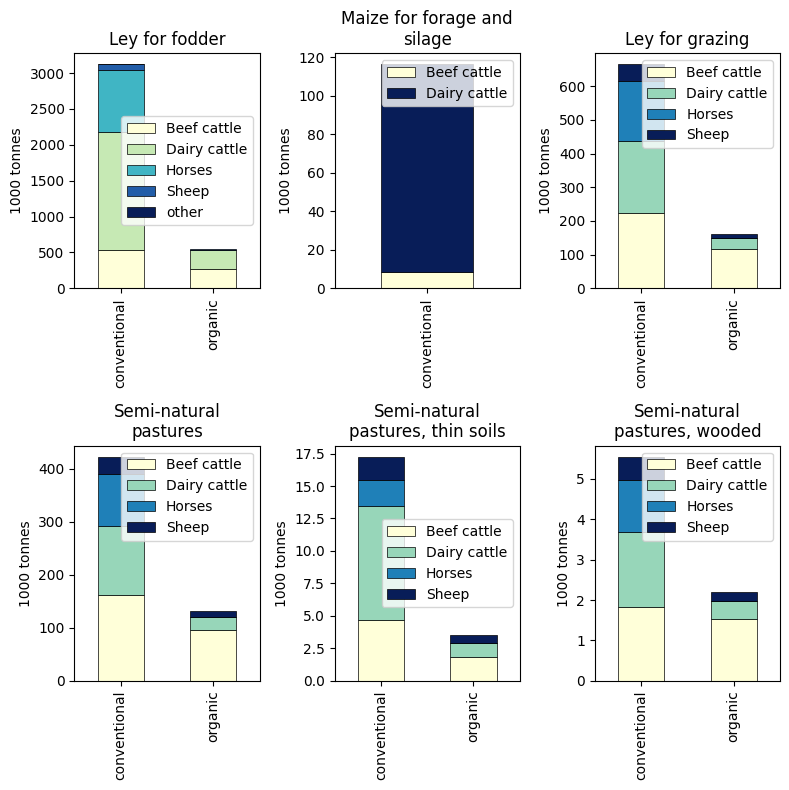

In [63]:
from textwrap import wrap
fig, axs = plt.subplots(2,3, figsize=(8,8))

for ax, cr in zip(
    axs.flatten(),
    ['Ley for fodder', 'Maize for forage and silage', 'Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']
):
    plot_data = (
        session.get_attr('c','production_per_use')
        .loc[(scn,year),cr]
        .groupby(['prod_system','demand'])
        .sum()
        .replace({0:np.nan})
        .dropna()
        .unstack()
    )/1000000
    plot_data.columns = ['Dairy cattle' if 'cattle, dairy' in c else 'Beef cattle' if 'cattle, beef' in c else 'Horses' if 'horses' in c else 'Sheep' if 'sheep' in c else 'other' for c in plot_data.columns]
    plot_data = plot_data.T.groupby(level=0).sum().T
    
    plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
    ax.set_title('\n'.join(wrap(cr, 20)))
    ax.set_ylabel('1000 tonnes')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Crop areas (deviation from x0)

#### Total crop areas

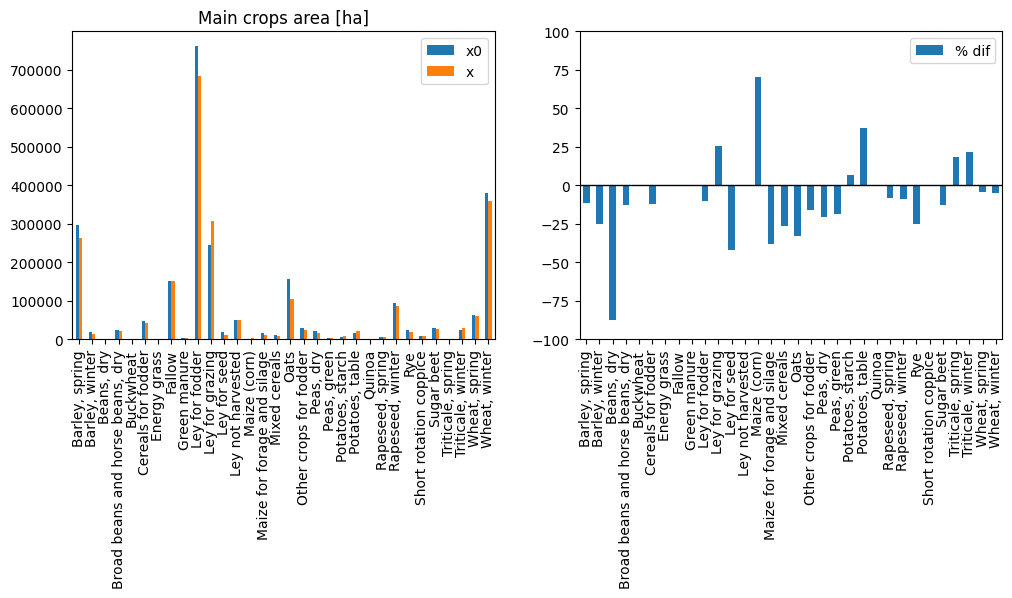

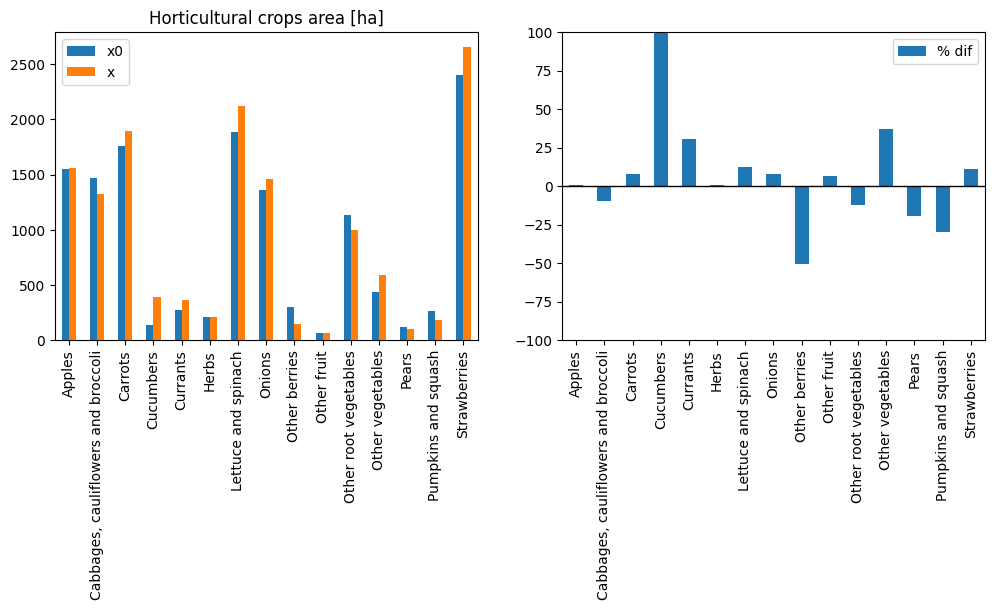

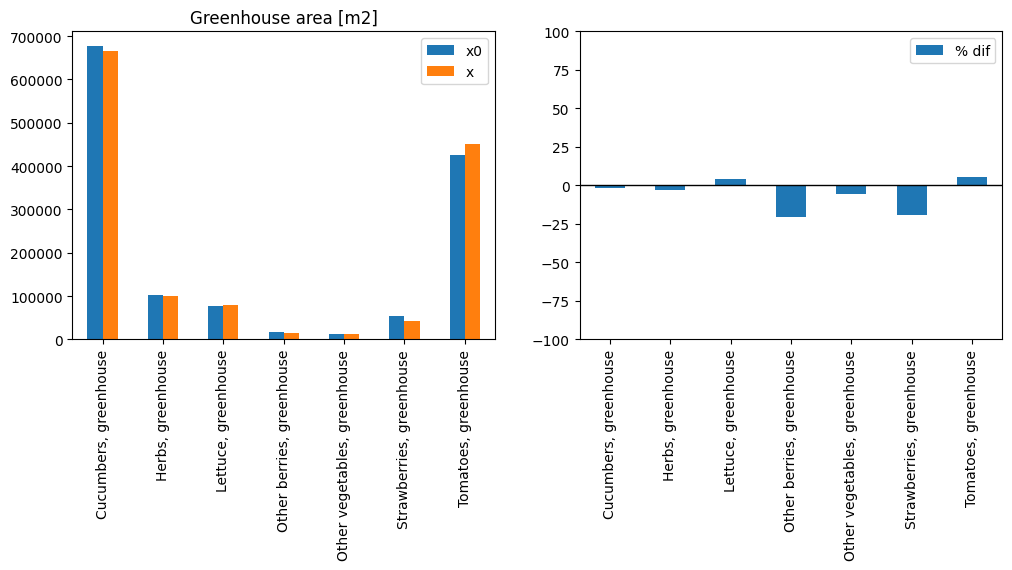

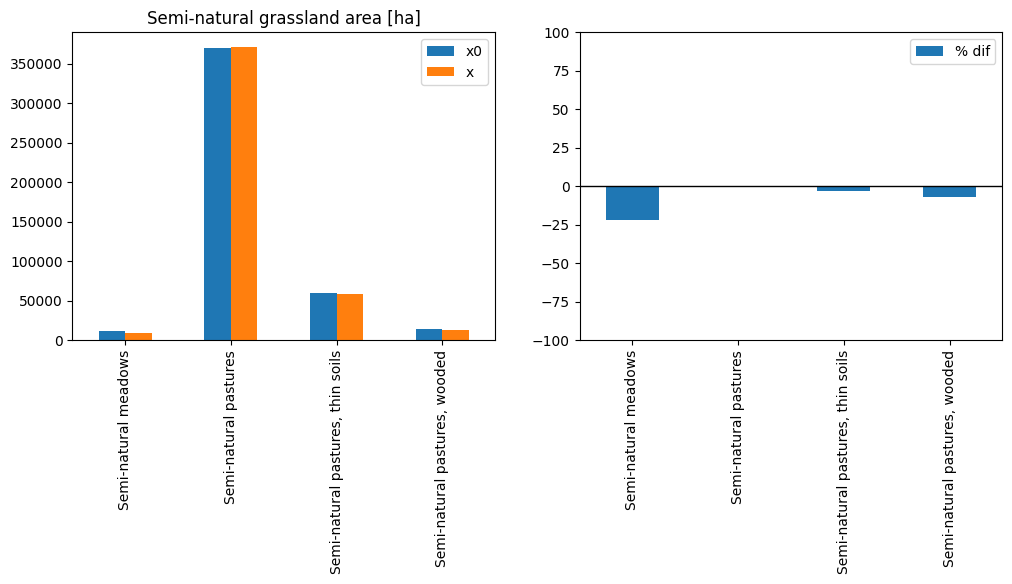

In [64]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['dif'] = plot_data.apply(lambda x:(x['x']-x['x0']), axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

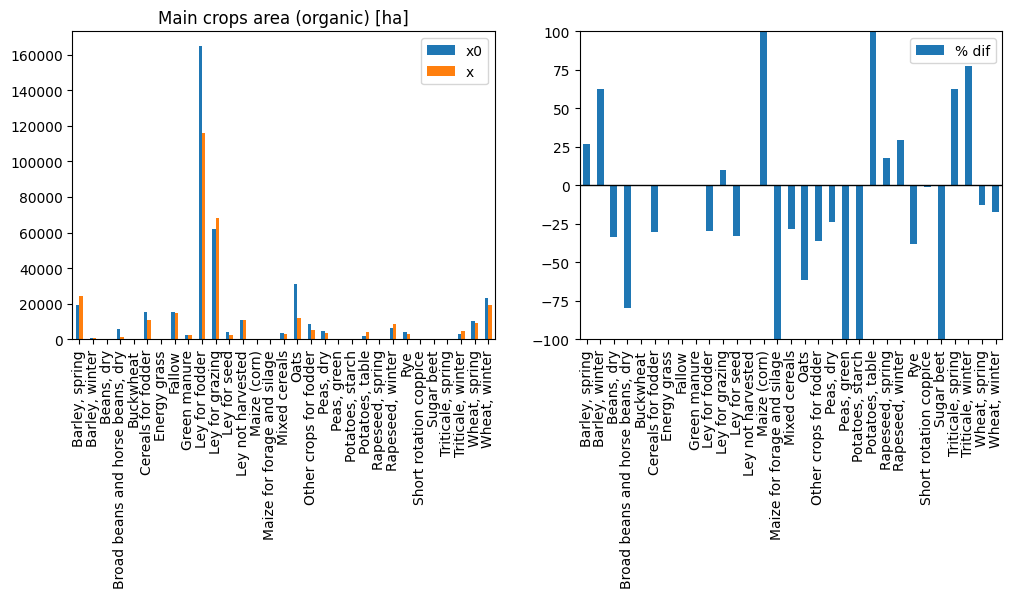

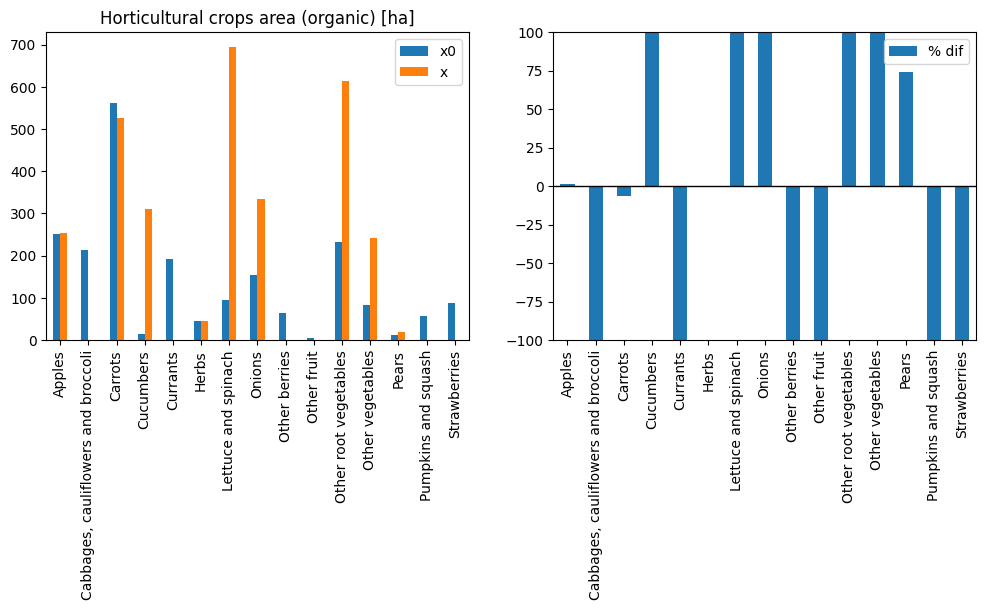

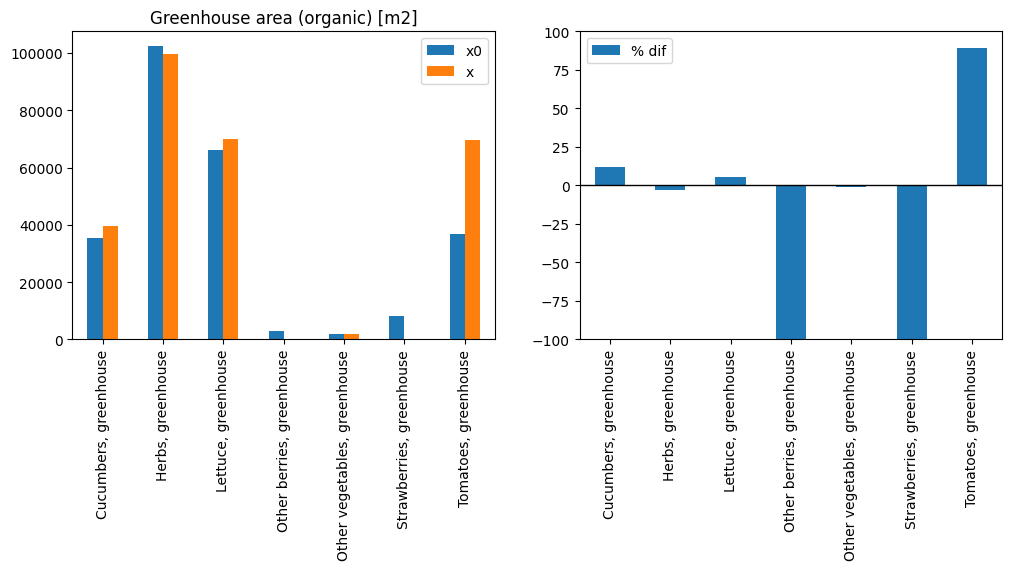

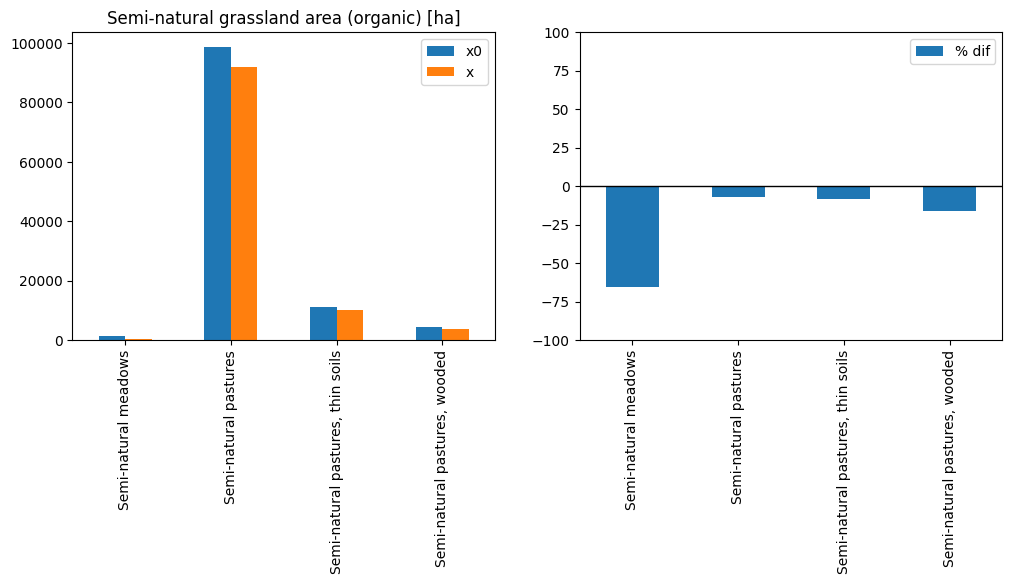

In [65]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop','prod_system']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop','prod_system']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

In [66]:
session.get_attr('C','area',['crop','region']).drop('base year (x0 crop areas)', level='scn').droplevel('year').rename(lambda x: x.replace('base year', 'x')).T

scn                             x   x (sp=0.2)   x (sp=0.8)
crop          region                                       
Apples        1011      25.099674    25.072526    24.942462
              111        0.000000     0.000000     0.000000
              1111     308.864036   308.516831   306.907607
              1112     153.606153   153.051230   152.060229
              112        6.134032     6.145730     6.111577
...                           ...          ...          ...
Wheat, winter 821     2297.020895  2247.766721  2383.630325
              831      354.960282   379.938595   163.703606
              911     1676.732262  1621.498996  1754.564658
              912     7853.203686  7926.885947  7910.787882
              913     1059.688171   995.554568  1123.229513

[6148 rows x 3 columns]

In [67]:
plot_data

,x,x0,% dif,cg
crop,,,,
Apples,253.622687,250.185850,1.373714,"Vegetables, berries and fruit"
"Barley, spring",24314.556191,19200.602538,26.634339,Cereals
"Barley, winter",829.671671,509.981412,62.686649,Cereals
"Beans, dry",35.860930,54.057075,-33.660988,Other arable
"Broad beans and horse beans, dry",1218.956828,6036.982485,-79.808508,Other arable
Buckwheat,0.000092,NaN,NaN,Other arable
"Cabbages, cauliflowers and broccoli",0.000000,212.857852,-100.000000,"Vegetables, berries and fruit"
Carrots,525.901160,561.874348,-6.402355,"Vegetables, berries and fruit"
Cereals for fodder,10733.466547,15374.868004,-30.188236,Fodder crops


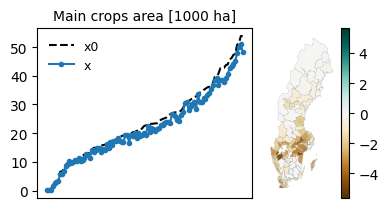

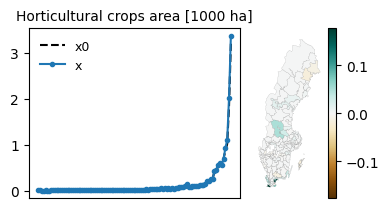

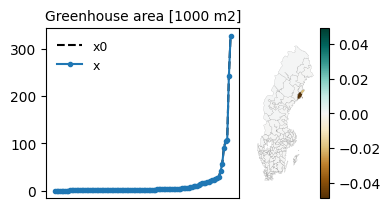

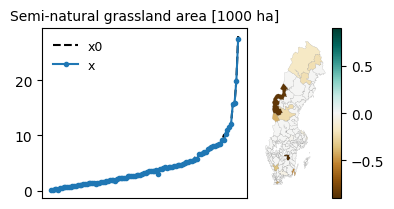

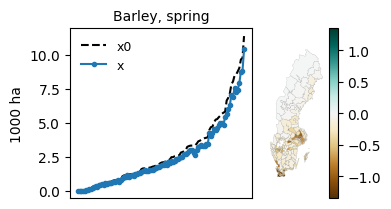

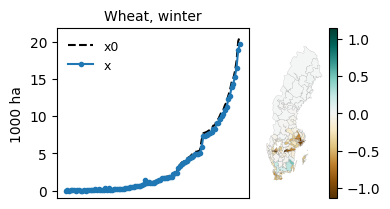

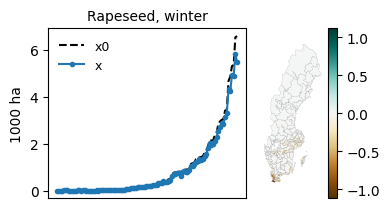

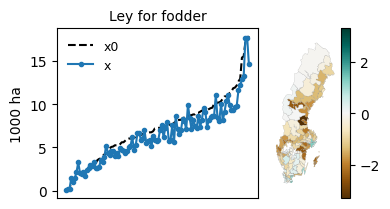

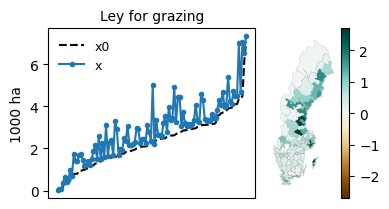

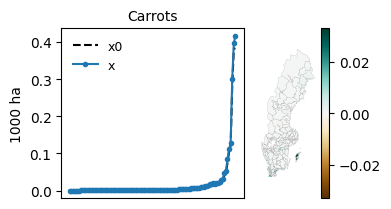

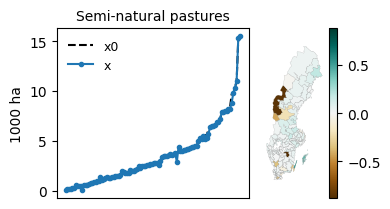

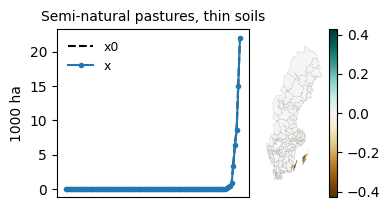

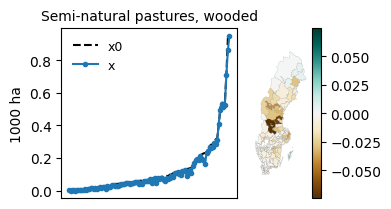

In [68]:
scns = ['base year']#, 'base year (sp=0.2)', 'base year (sp=0.8)']

plot_data_ = (
    pd.concat([
        session.get_attr('C','area',['crop','region']).droplevel('year').loc[scns].rename(lambda x: x.replace('base year', 'x')).T,
        session.get_attr('R','x0_crops',['crop','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)/1000

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [1000 ha]' : cr,
    'Horticultural crops area [1000 ha]' : hr,
    'Greenhouse area [1000 m2]' : gh,
    'Semi-natural grassland area [1000 ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 0.8]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in scns], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(p, size=10)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(0, 1), loc='upper left', fontsize=9, frameon=False)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Some main crops
crps = ['Barley, spring','Wheat, winter','Rapeseed, winter','Ley for fodder','Ley for grazing','Carrots','Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 0.8]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in scns], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(crp, size=10)
    ax.set_xlabel('')
    ax.set_ylabel('1000 ha')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(0, 1), loc='upper left', fontsize=9, frameon=False)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

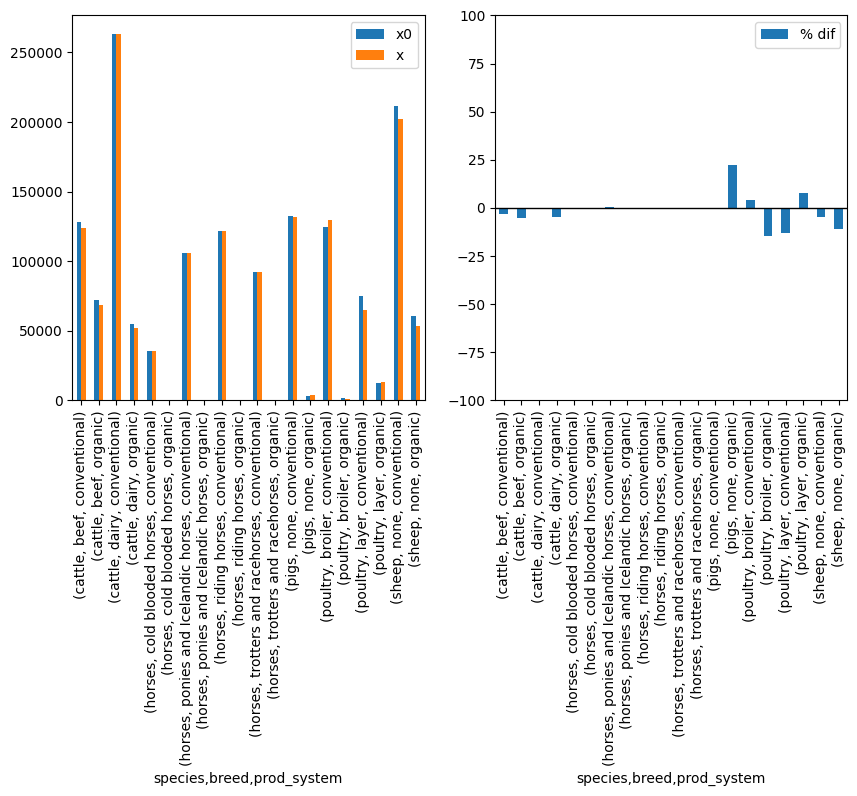

In [69]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['region','species','breed','prod_system','animal'])
        .droplevel('year')
        .rename(lambda x: x.replace('base year','x'))
        .T
        .loc[idx[:,:,:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['region','species','breed','prod_system'])
        .sum()
        ,
        session.get_attr('R','x0_animals',['region','species','breed','prod_system']).loc[(scn,year)]
        .rename('x0')
    ], axis=1)
)

# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

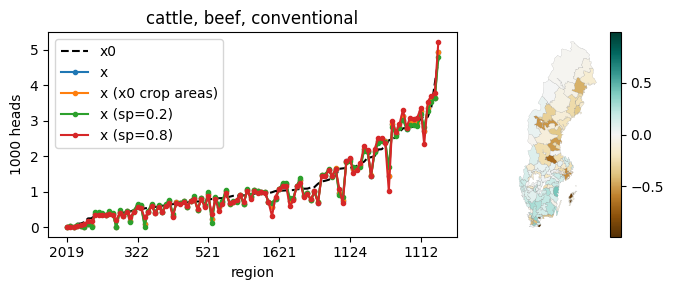

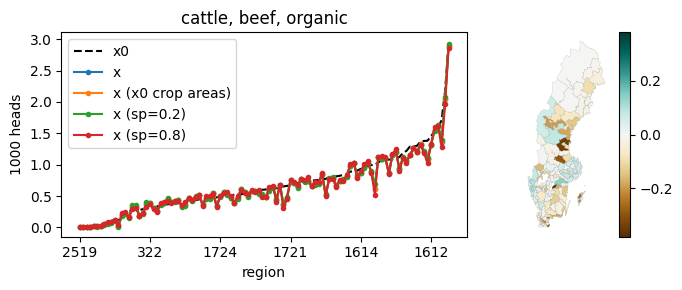

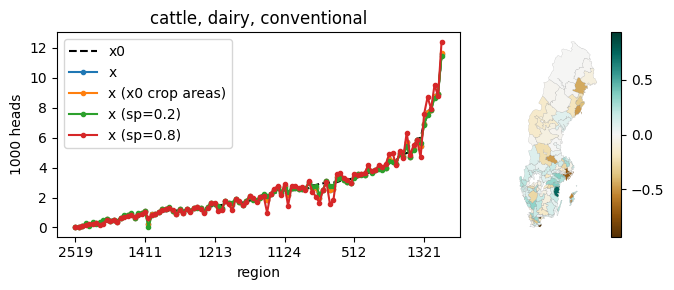

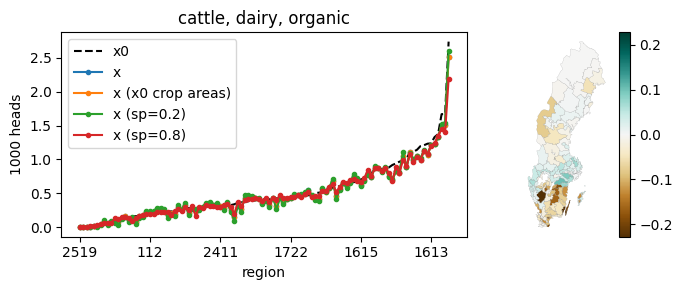

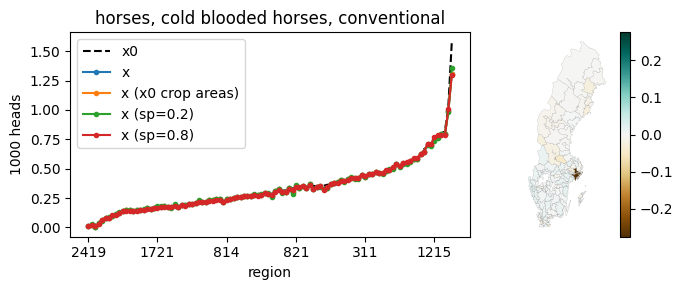

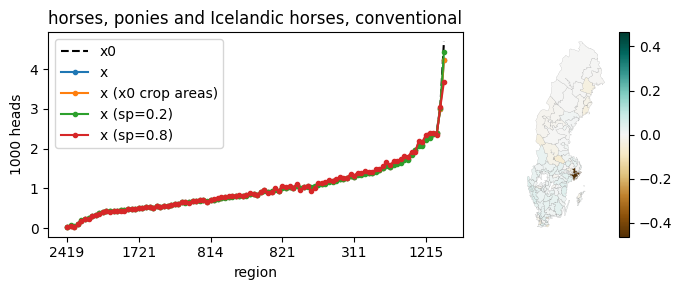

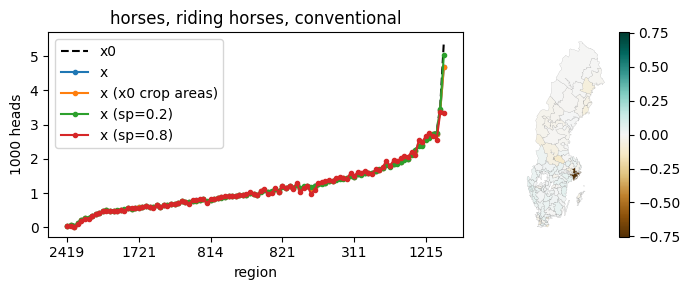

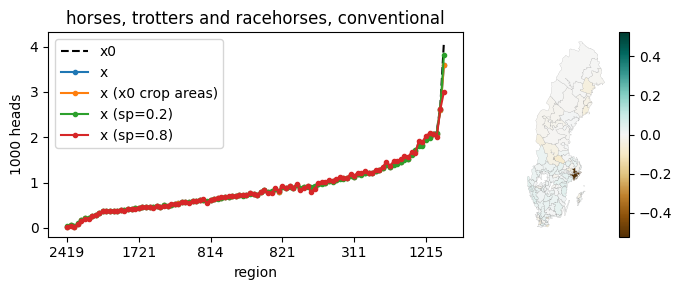

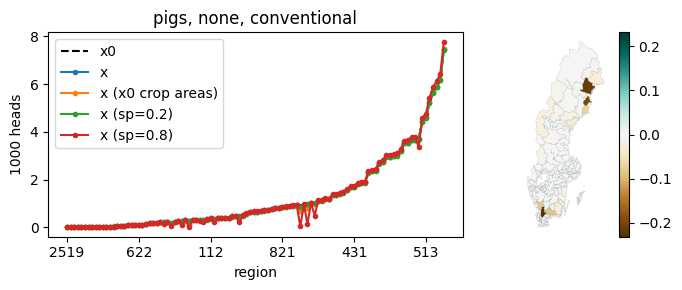

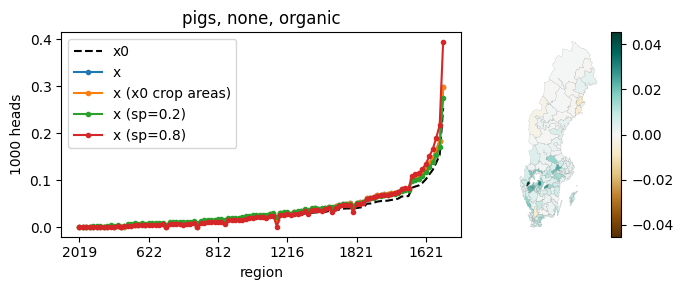

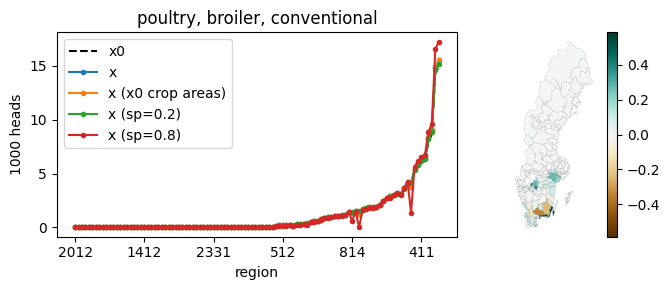

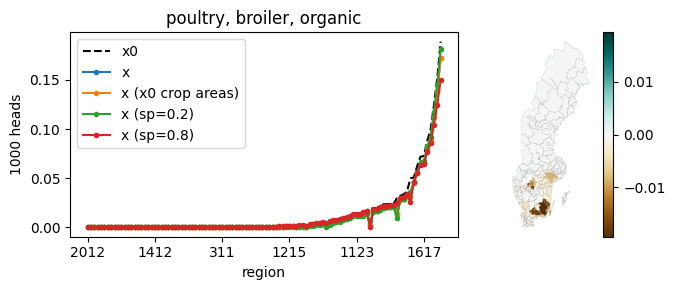

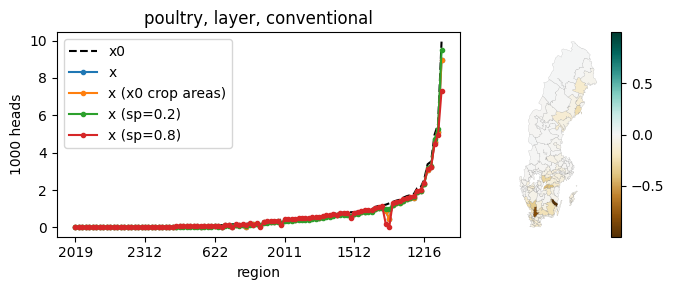

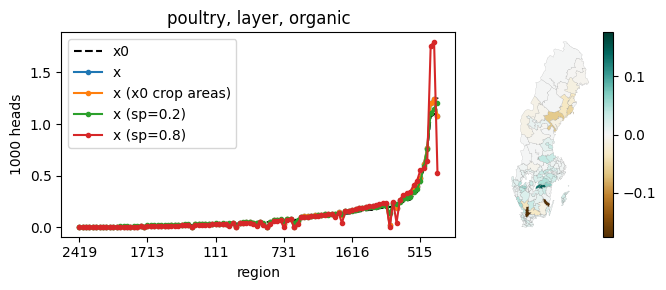

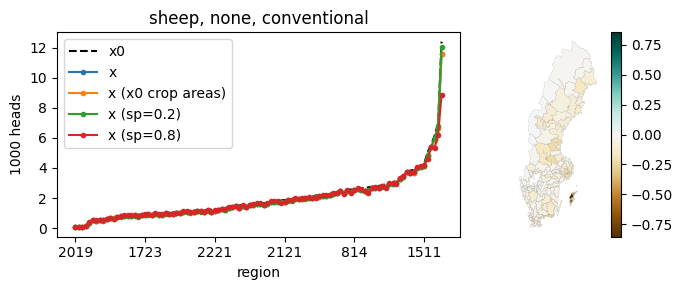

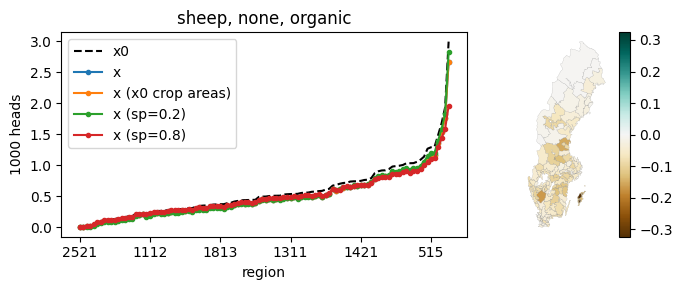

In [70]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()/1000
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in session.scenarios('has output')], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(', '.join(idx))
    ax.set_ylabel('1000 heads')

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

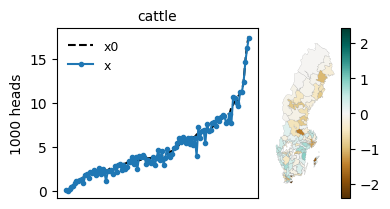

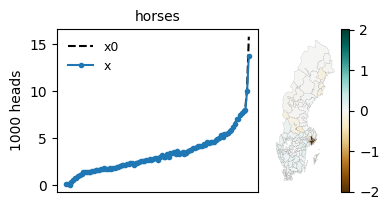

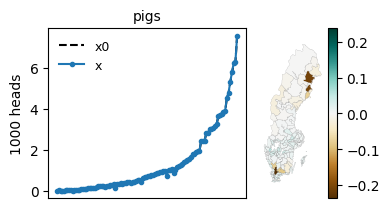

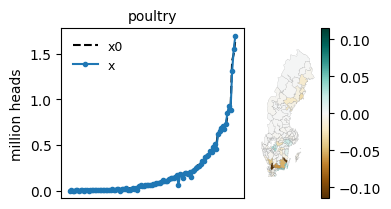

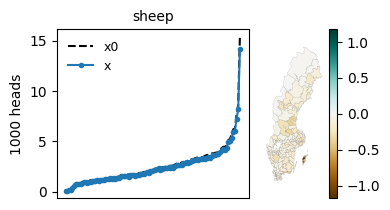

In [71]:
idx = pd.IndexSlice

scns = ['base year']#, 'base year (sp=0.2)', 'base year (sp=0.8)']

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['species','region','animal']).droplevel('year').loc[scns].rename(lambda x: x.replace('base year', 'x')).T
        .loc[idx[:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['species','region']).sum(),
        session.get_attr('R','x0_animals',['species','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)/1000

for sp in plot_data_.index.unique('species'):
    plot_data = plot_data_.loc[sp].copy() * (1/1000 if sp == 'poultry' else 1)
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 0.8]})
    ax=axs[0]
    plot_data.plot(ax=ax, y='x0', kind='line', marker='', linestyle='--', color='black')
    plot_data.plot(ax=ax, y=[c.replace('base year','x') for c in scns], kind='line', marker='.', linestyle='-')
    # ax.set_yscale('log')
    ax.set_title(sp, size=10)
    ax.set_xlabel('')
    ax.set_ylabel(f'{"million" if sp == "poultry" else "1000"} heads')
    ax.set_xticks([])
    ax.legend(bbox_to_anchor=(0, 1), loc='upper left', fontsize=9, frameon=False)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

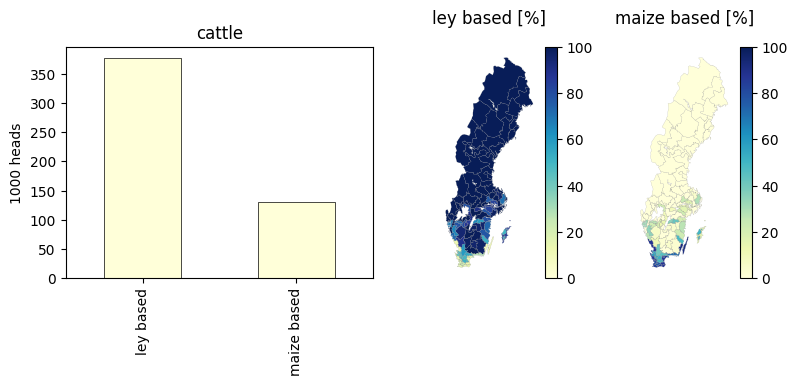

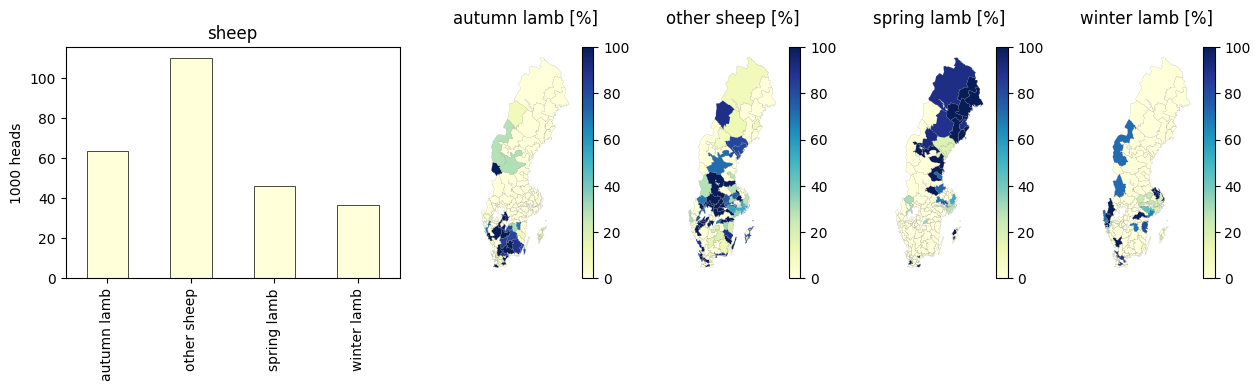

In [72]:
idx = pd.IndexSlice
plot_data = (
    session.get_attr('A','heads',['species','sub_system','region','animal']).loc[(scn,year)]
    .loc[idx[:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
            'ewes','rams'
        ]]]
    .groupby(['species','sub_system','region'])
    .sum()
)/1000


for sp in plot_data.index.get_level_values('species').unique():
    plot_data_ = plot_data.xs(sp)
    sss = plot_data_.index.get_level_values('sub_system').unique()
    n_ss = len(sss)
    if n_ss>1:
        fig, axs = plt.subplots(1, 1+n_ss, figsize=(3+3*n_ss,3), gridspec_kw={'width_ratios': [2] + [1]*n_ss})
        ax=axs[0]
        plot_data_.groupby('sub_system').sum().plot(**pd_bar_style, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('1000 heads')
        ax.set_title(sp)
        
        map_data = plot_data_.groupby('region').transform(lambda x: x/x.sum() * 100)
        for ax,ss in zip(axs[1::],sss):
            plot.map_from_series(
                map_data.xs(ss),
                ax=ax,
                vmin=0,
                vmax=100,
                **map_style
            )
            ax.set_title(ss + ' [%]')
            ax.axis('off')
            
        plt.show()

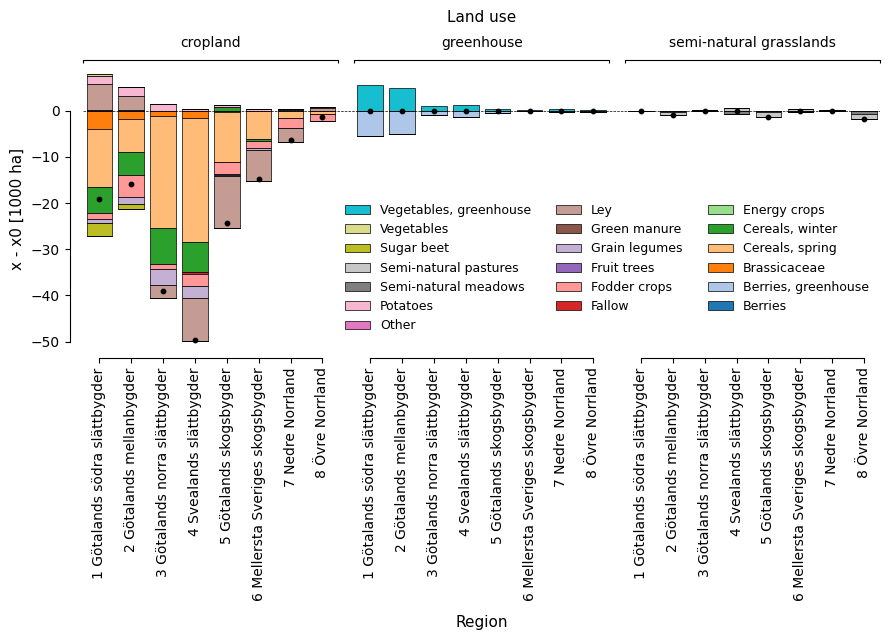

In [73]:
fig = plt.figure(figsize=(9,6.5))
data = (
    (session.get_attr('cr','area',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0] -
    session.get_attr('r','x0_crops',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0]) / 1000
).unstack('crop_group')
ax = plot.bar(data, stacked=True, group_levels='land_use', sort_xlabels=False, sort_groups=False, cmap='tab20', grouptitle='Land use', xlabel='Region', ylabel='x - x0 [1000 ha]')

plt.tight_layout()
plt.show()

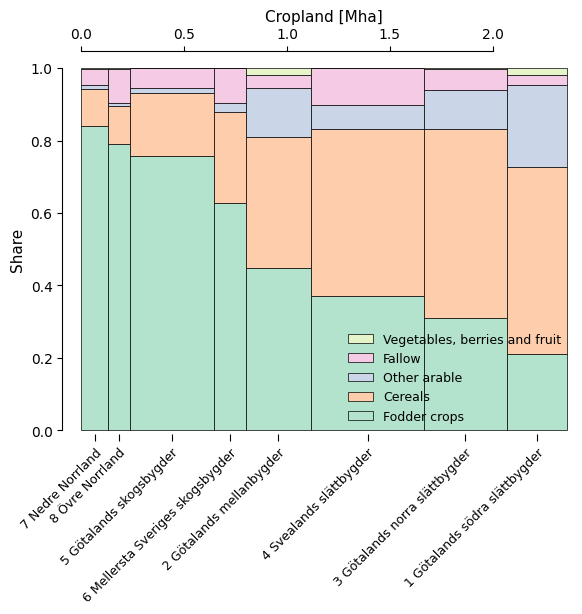

In [74]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'],'region':'po8'}).iloc[0].loc['cropland'].unstack('crop_group2') / 1000000
ax = plot.marimekko(data, xlabel='Cropland [Mha]', ylabel='Share', cmap='Pastel2')
plt.show()

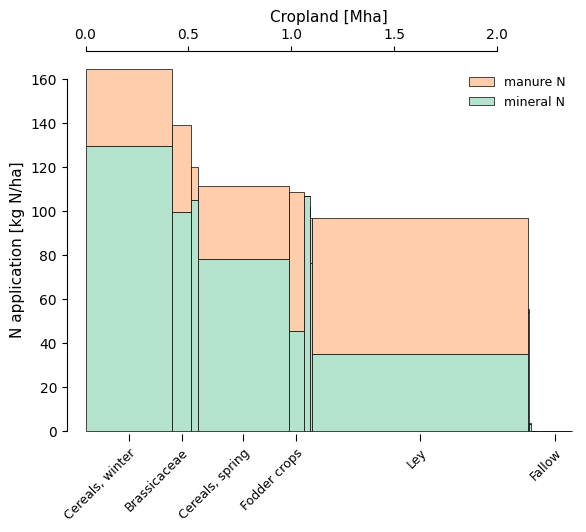

In [75]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral N'),
    session.get_attr('c','fertiliser.manure_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure N'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='N application [kg N/ha]', cmap='Pastel2')
plt.show()

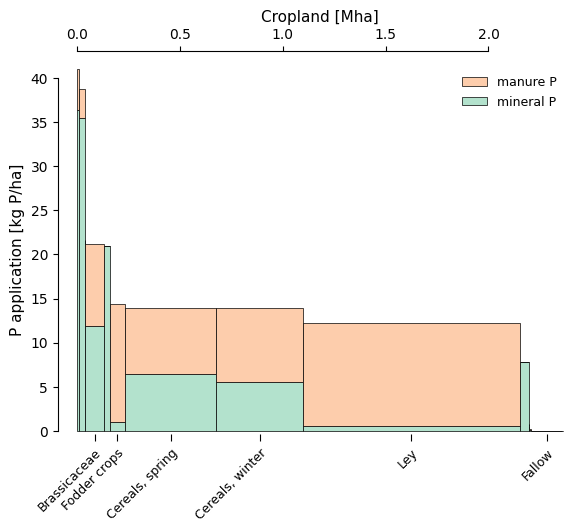

In [76]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral P'),
    session.get_attr('c','fertiliser.manure_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure P'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='P application [kg P/ha]', cmap='Pastel2', xcategorylabels_threshold=0.02, xcategorylabels_fontsize=9)
plt.show()

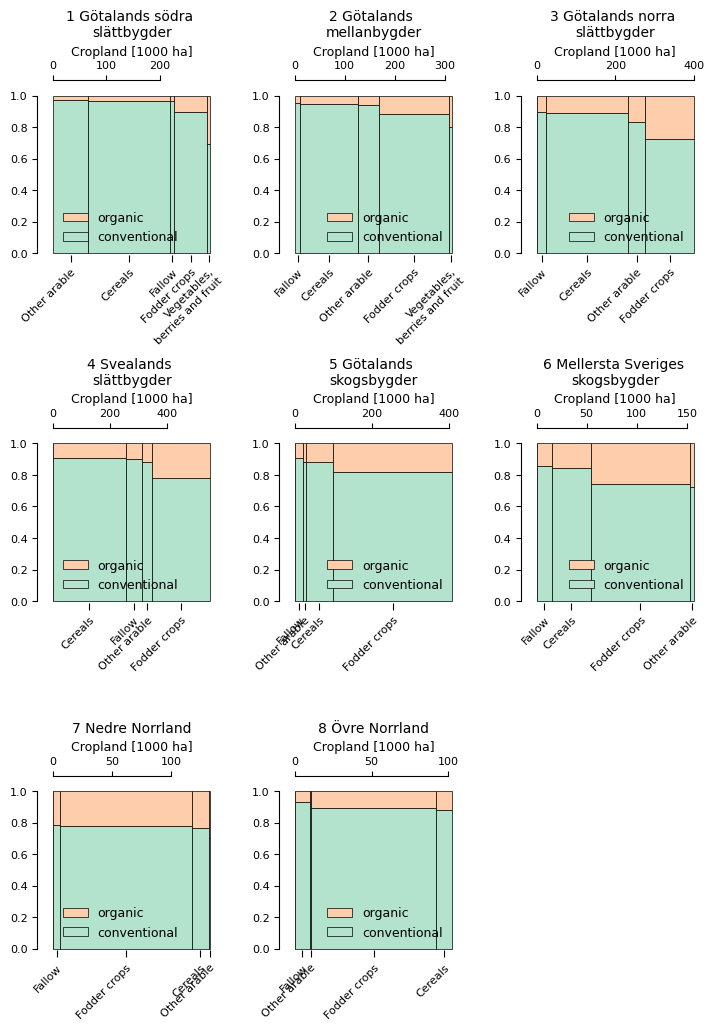

In [77]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'], 'region':'po8', 'prod_system':None}).iloc[0].loc['cropland'].unstack()/1000
fig, axs = plot.subplots(data, index='po8', plot_fn=plot.marimekko, size=(2.5,3.5), cmap='Pastel2', title_fontsize=10, xcategorylabels_threshold=0.01,
                         xcategorylabels_wrap=18, xcategorylabels_fontsize=8, xlabel='Cropland [1000 ha]', xlabel_fontsize=9, ticklabels_fontsize=8)
plt.tight_layout(pad=2)
plt.show()

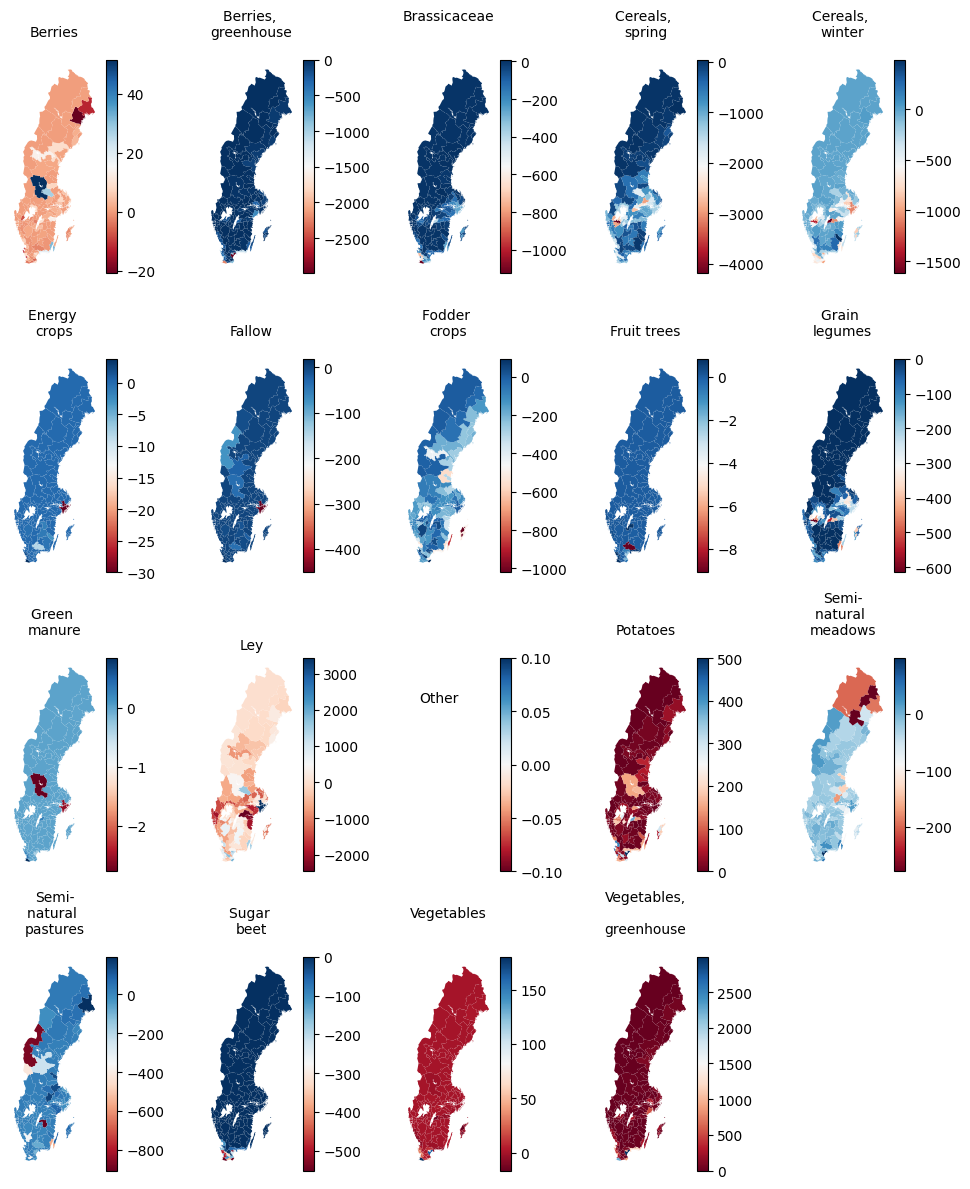

In [78]:
data = (session.get_attr('c','area',{'crop':'crop_group','region':None}) - session.get_attr('r','x0_crops',{'crop':'crop_group','region':None})).iloc[0]

fig, axs = plot.subplots(data, index='crop_group', title_fontsize=10, size=(2,3), plot_fn=plot.map_from_series, cmap='RdBu')
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

## Run baseline calculations

In [16]:
%%time
cm.ParameterRetriever.update_relation_tables()
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

CPU times: total: 8.64 s
Wall time: 9.72 s


In [ ]:
%%time
# Set to true to print progress messages
msg = True
scale_powers = {
    'base year (sp=0.2)' : 0.2,
    'base year (sp=0.8)' : 0.8,
}

# Loop through scenarios and years
for scn, year in session.iterate('base year'):
    print(scn,year)
    # Reload parameter data
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=scale_powers.get(scn, 0.4), verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg, apply_solution=False)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with {type(e).__name__}: {e}')
        continue

    if 'x0 crop areas' in scn:
        # Set crop areas to x0 areas (for validation)
        geodist.x['crp'] = geodist.x0['crp']

    # Apply solution
    geodist.apply_solution()
        
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )